# Run this to enable loading from relative paths

In [1]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
    root_parent_level = 1
    import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
    PKG = %pwd
    PKG = pathlib.Path(PKG)
    root = PKG
    full_pkg = f"{root.name}"
    for _ in range(root_parent_level):
        root = root.parent
        full_pkg = f"{root.name}.{full_pkg}"
        MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
        MODULE_NAME = f"{root.name}"
        spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
        module = importlib.util.module_from_spec(spec)
        sys.modules[spec.name] = module
        spec.loader.exec_module(module)
    __package__ = full_pkg


# Force matplotlib inlining 

In [2]:
%matplotlib inline

# Save plots with no embeded fonts

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']


# Figures Save Path

In [4]:
# save_prefix = r"../results/opto/"
import os
save_prefix = os.environ["OnedriveCommercial"] + r"/analysis/ver2/opto_new/"
import pathlib
try:
    pathlib.Path(save_prefix).mkdir(exist_ok=True)
    pathlib.Path(f"{save_prefix}/Performance").mkdir(exist_ok=True)
    pathlib.Path(f"{save_prefix}/RT").mkdir(exist_ok=True)
    pathlib.Path(f"{save_prefix}/Psychometric").mkdir(exist_ok=True)
except:
    print("Failed to create save dir...")

# Load Data

In [5]:
import pandas as pd
FP = "../data/opto/df_opto.pkl"
df_opto = pd.read_pickle(FP)

In [6]:
FP_CONTROL = "../data/opto/df_opto_control.pkl"
df_opto_control = pd.read_pickle(FP_CONTROL)

In [7]:
df_opto = pd.concat([df_opto, df_opto_control]).reset_index(drop=True)

In [8]:
# IMP_COLS
df_opto.columns

Index(['AuditoryTrial', 'BlockId', 'BlockNum', 'BlocksInfo', 'CatchTrial',
       'CenterPortRewAmount', 'ChoiceCorrect', 'ChoiceLeft', 'DV',
       'DVsAlreadyGenerated',
       ...
       'PrevCalcStimulusTime2', 'PrevCalcStimulusTime4',
       'PrevCalcStimulusTime3', 'PrevChoiceCorrect', 'PrevChoiceLeft', 'Stay',
       'PrevLefRewarded', 'StayBaseline', 'DVstr', 'PrevDVstr'],
      dtype='object', length=117)

In [11]:
# display(df_opto[df_opto.Name.str.startswith("WF")][["Name", "Rig", "GUI_StimulusTime", "MinSample", "OptoEnabled", "GUI_OptoMaxTime"]].value_counts().sort_index())

def fixWF(df):
    df = df.copy()
    df.loc[df.Name.str.startswith("WF") & (df.MinSample >= .955) & (df.MinSample < 1),"MinSample"] = 1.0

    df.loc[(df.Name == "WF14"), "MinSample"] = df[(df.Name == "WF10")].MinSample.iloc[0]
    # assert df_opto[df_opto.Name == "WF10"].GUI_OptoMaxTime.nunique() == 1 # 1.5s
    # assert df_opto[df_opto.Name == "WF14"].GUI_OptoMaxTime.nunique() == 1 # 2.0s
    df.loc[(df.Name == "WF14"), "GUI_OptoMaxTime"] = df[(df.Name == "WF10")].GUI_OptoMaxTime.iloc[0]
    # assert df_opto[df_opto.Name == "WF10"].GUI_StimulusTime.nunique() == 1 # 1.5s
    # assert df_opto[df_opto.Name == "WF14"].GUI_StimulusTime.nunique() == 1 # 2.0s
    df.loc[(df.Name == "WF14"), "GUI_StimulusTime"] = df[(df.Name == "WF10")].GUI_StimulusTime.iloc[0]
    # Only WF_Thy1-2 and this was set to Opto config without Opto-Probo;otu turned on, i.e. it has no opto enabled trials
    df = df[~df.Rig.str.startswith("LarkumPCWin10")]
    # WF12 was set to V1 and it has no control trials, it was set by mistake
    df = df[~(df.Name == "WF12")]
    return df

df_opto = fixWF(df_opto)
display(df_opto[df_opto.Name.str.startswith("WF")][["Name", "Rig", "GUI_StimulusTime", "MinSample", "OptoEnabled", "GUI_OptoMaxTime"]].value_counts().sort_index())

Name  Rig     GUI_StimulusTime  MinSample  OptoEnabled  GUI_OptoMaxTime
WF10  FR03\n  1.5               1.0        0.0          1.5                534
                                           1.0          1.5                126
WF13  FR03\n  1.5               1.0        0.0          1.5                437
                                           1.0          1.5                 84
WF14  FR03\n  1.5               1.0        0.0          1.5                136
                                           1.0          1.5                 25
dtype: int64

In [12]:
from .behavior.util.splitdata import splitStimulusTimeByQuantile

print([col for col in df_opto.columns if "pulse" in col.lower()])
# df_opto.query("abs(GUI_OptoStartDelay - 0.3) < 0.001 and "
#                                  "abs(GUI_OptoMaxTime - 0.6) < 0.001 and "
#                                 f"GUI_OptoStartState1 == {int(MatrixState.stimulus_delivery)}")[["calcStimulusTime",  'PrevCalcStimulusTime1',  'PrevCalcStimulusTime2',]]
from .behavior.rewardrate import calcAvgRewardRate
def _setPulseSessToNoOpto(sess_df):
    sess_df = sess_df.copy()
    if ((sess_df.DotsPulseCoherence > 0) & (sess_df.DotsPulseDur > 0)).any():
        print(f"Setting sess {sess_df.Name.iloc[0]} {sess_df.Date.iloc[0]} {sess_df.SessionNum.iloc[0]} to no opto")
        sess_df["OptoEnabled"] = 0
        sess_df["PrevOptoEnabled"] = 0
    sess_df["PrevOptoEnabled"] = sess_df["OptoEnabled"].shift(1)
    #
    sess_df["PrevOptoEnabled2"] = sess_df["PrevOptoEnabled"].shift(1)
    sess_df = calcAvgRewardRate(sess_df)
    return sess_df

def assignQuantilesWithoutOpto(df):
    df = df.reset_index(drop=True)
    # Some files are saved twice due to cloud sync issues
    uniq_cols = ["Name", "Date", "SessionNum", "TrialNumber", "TrialStartSysTime"]
    # dups_idxs = df[uniq_cols].duplicated(keep=False).values
    # display(df[dups_idxs])
    df = df[~df[uniq_cols].duplicated(keep="first")]
    df = df[df.calcStimulusTime.notnull()]
    df_opto = df[df.OptoEnabled == 1]
    df = df[df.OptoEnabled == 0]
    df = splitStimulusTimeByQuantile(df)
    df = pd.concat([q_df for q_idx, q_df in df])
    # Now assign quantiles to opto trials based on the no-opto trials in the same session
    for (name, date, sess_num), sess_df in df_opto.groupby(["Name", "Date", "SessionNum"]):
        no_opto_sess_df = df[(df.Name == name) & (df.Date == date) &
                             (df.SessionNum == sess_num)]
        if no_opto_sess_df.empty:
            print(f"No no-opto trials for sess {name} {date} {sess_num}? - Sess length: {len(sess_df)}")
            continue
        # We have three quantile_idx, find the edges
        q_lowest_upper = no_opto_sess_df[no_opto_sess_df.quantile_idx == 1].calcStimulusTime.max()
        q_highest_lower = no_opto_sess_df[no_opto_sess_df.quantile_idx == 3].calcStimulusTime.min()
        # Assign quantile idx to opto trials
        df_opto.loc[sess_df.index, "quantile_idx"] = 2
        df_opto.loc[sess_df.index[sess_df.calcStimulusTime < q_lowest_upper], "quantile_idx"] = 1
        df_opto.loc[sess_df.index[sess_df.calcStimulusTime >= q_highest_lower], "quantile_idx"] = 3
    df = pd.concat([df, df_opto]).sort_index()
    return df

df_opto_fix = df_opto.groupby(["Name", "Date", "SessionNum"], group_keys=False).apply(_setPulseSessToNoOpto)
df_opto_fix = assignQuantilesWithoutOpto(df_opto_fix)

['DotsPulseCoherence', 'DotsPulseDur', 'DotsPulseStart']
Setting sess BVAGT4 2022-02-21 1 to no opto
Setting sess BVAGT4 2022-02-21 2 to no opto
Setting sess BVAGT4 2022-02-22 1 to no opto
Setting sess BVAGT4 2022-02-23 1 to no opto
Setting sess BVAGT4 2022-02-24 3 to no opto
Setting sess BVAGT4 2022-02-25 1 to no opto
Setting sess BVAGT4 2022-02-27 1 to no opto


  0%|          | 0/494 [00:00<?, ?it/s]

No no-opto trials for sess Avgat1 2021-08-17 4? - Sess length: 1
No no-opto trials for sess BVAGT4 2021-11-15 4? - Sess length: 1
No no-opto trials for sess BVAGT4 2021-11-17 3? - Sess length: 15
No no-opto trials for sess vgat2.5 2021-02-09 1? - Sess length: 13
No no-opto trials for sess vgat2.6 2020-11-03 4? - Sess length: 3


In [13]:
from .common.definitions import BrainRegion, MatrixState

df_opto_feedback = pd.read_csv('../data/opto/df_opto_feedback.csv')
df_opto_feedback["GUI_OptoBrainRegion"] = df_opto_feedback.Group.map({
    "LFC": int(BrainRegion.ALM_Bi), "MFC": int(BrainRegion.M2_Bi)})
df_opto_feedback = df_opto_feedback[df_opto_feedback.GUI_OptoOr2P == 1]
df_opto_feedback = df_opto_feedback[df_opto_feedback.GUI_OptoStartState1.isin([int(MatrixState.WaitForReward), int(MatrixState.WaitForPunish)])]
df_opto_feedback = df_opto_feedback[df_opto_feedback.GUI_OptoStartState2.isin([int(MatrixState.WaitForReward), int(MatrixState.WaitForPunish)])]
df_opto_feedback = df_opto_feedback[df_opto_feedback.GUI_OptoMaxTime <= 3]
df_opto_feedback = df_opto_feedback[df_opto_feedback.GUI_OptoBrainRegion.isin([int(BrainRegion.ALM_Bi), int(BrainRegion.M2_Bi)])]
#
df_opto_feedback["GUI_OptoStartDelay"] = df_opto_feedback["GUI_OptoStartDelay"].mode()[0]
df_opto_feedback["GUI_OptoMaxTime"] = df_opto_feedback["GUI_OptoMaxTime"].mode()[0]
assert set(df_opto_feedback.GUI_OptoStartState1.unique()) == set([int(MatrixState.WaitForReward), int(MatrixState.WaitForPunish)])
assert set(df_opto_feedback.GUI_OptoStartState2.unique()) == set([int(MatrixState.WaitForReward), int(MatrixState.WaitForPunish)])
df_opto_feedback["GUI_OptoStartState1"] = int(MatrixState.WaitForReward)
df_opto_feedback["GUI_OptoStartState2"] = int(MatrixState.WaitForPunish)
df_opto_feedback = df_opto_feedback[df_opto_feedback.Group != "Control"]
display(df_opto_feedback[["GUI_OptoStartDelay", "GUI_OptoMaxTime", "GUI_OptoStartState1", "GUI_OptoStartState2", "GUI_OptoBrainRegion"]].value_counts())
df_opto_feedback[["Name", "GUI_OptoBrainRegion"]].value_counts().sort_index()
display(df_opto_feedback[["GUI_OptoStartDelay", "GUI_OptoMaxTime", "GUI_OptoStartState1", "GUI_OptoStartState2", "GUI_OptoBrainRegion"]].value_counts())
df_opto_feedback[["Name", "GUI_OptoBrainRegion"]].value_counts().sort_index()
print(len(df_opto_feedback[df_opto_feedback.Group != "Control"]))
print(len(df_opto_feedback))
# Filter out sessions with very few opto trials
# df_opto_feedback = df_opto_feedback.groupby(["Name", "Date", "SessionNum"]).filter(
#                                  lambda sess_df:((sess_df.OptoEnabled == 1) & (sess_df.PrevhoiceCorrect == 0).sum() > 5))

GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoStartState1  GUI_OptoStartState2  GUI_OptoBrainRegion
0.2                 3.0              16                   22                   15.0                   9381
                                                                               6.0                    6464
dtype: int64

GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoStartState1  GUI_OptoStartState2  GUI_OptoBrainRegion
0.2                 3.0              16                   22                   15.0                   9381
                                                                               6.0                    6464
dtype: int64

15845
15845


In [ ]:
# df_opto.to_pickle(r"../data/opto/df_opto_ft.pkl")
# df_opto_fix.to_pickle(r"../data/opto/df_opto_rt.pkl")
# df_opto_feedback.to_pickle(r"../data/opto/df_opto_feedback.pkl")

# Helping function

In [ ]:
from .opto.optoprocessor import loopConfig
from common.definitions import ExperimentType
from typing import Literal


def loopPlotOptoEffect(df, applyFn, single_subjects,
                       min_choice_trials,
                       which : Literal["partial", "full", "all", "feedback"] = "all",
                       stim_type : Literal["FT", "RT", "all"] = "all",
                       process_groups_together=False,
                       only_control_animals=False,
                       save_prefix="", save_figs=False):
    df = df.copy()
    df = df[df.GUI_ExperimentType == ExperimentType.RDK]
    control_animals = df.Name.str.startswith("WF")
    if only_control_animals:
        df = df[control_animals]
        display(df.agg({'GUI_StimulusTime': ['count', "min", "max", "mean"],
                      'MinSample': ['min', 'max', 'mean',],
                      "calcStimulusTime": ["min", "max", "mean",],
                      "ST": ["min", "max", "mean",],
                      "Date": ["min", "max"],
                     }))
        display(df[["Name", "GUI_OptoBrainRegion"]].value_counts())
    else:
        df = df[~control_animals]
    # Filter out sessions with very few opto trials
    df = df.groupby(["Name", "Date", "SessionNum"]).filter(
                                 lambda sess_df:sess_df.OptoEnabled.sum() > 10)
    # Run the actual analysis
    return loopConfig(df, applyFn,
                      #which="full",
                      #which="partial",
                      #stim_type="FT",
                      min_choice_trials=min_choice_trials,
                      stim_type=stim_type, which=which,
                      process_groups_together=process_groups_together,
                      single_subjects=single_subjects,
                      save_prefix=save_prefix, save_figs=save_figs)



In [ ]:
df_opto.Name.value_counts()

vgat2.6    13555
vgat-94    12755
vgat2.5    12407
vgat-96    11856
vgat-46    11185
vgat-40    10799
BVAGT4      7942
BVGAT3      7619
vgat2.4     6417
BVGAT1      5241
BVGAT2      4363
vgat2.1     4348
Avgat1      2983
BVGAT5      2263
VM2         1577
Avgat3      1480
Avgat4      1320
WF10         660
WF13         521
Avgat2       515
Sim-cre      207
WF14         161
vgat-95       82
Name: Name, dtype: int64

# Bars

In [23]:
early_late_ft_df = df_opto.query("(GUI_OptoStartDelay == 0 and GUI_OptoMaxTime == 0.35) or "
                              "(GUI_OptoStartDelay == .65 and GUI_OptoMaxTime == 0.35)")
full_ft_df = df_opto.query("GUI_OptoStartDelay == 0 and GUI_OptoMaxTime == 1")

ValueError: Only callable can be used as callback

In [20]:
from .opto.optoprocessor import EffectSizeMetric, plotOptoEffect
from .opto.optoprocessor import SplitLevelBy
from .common.definitions import BrainRegion
from functools import partial


_split_level = SplitLevelBy.Animal
applyFnAll = partial(plotOptoEffect, df_col_name="ChoiceCorrect",
                     split_level=_split_level,
                     mean_or_median="mean",
                     #   only_brain_regions=[BrainRegion.ALM_Bi, BrainRegion.M2_Bi],
                     only_brain_regions=[BrainRegion.ALM_Bi, BrainRegion.M2_Bi, BrainRegion.PPC_Bi, BrainRegion.V1_Bi],
                     effect_size_metric=EffectSizeMetric.Gain,
                     # effect_size_metric=EffectSizeMetric.DistanceFromRandom, # CohenD
                    num_iterations=10_000,
                )

In [21]:


used_full_ft_df = loopPlotOptoEffect(full_ft_df, applyFn=applyFnAll, single_subjects=False,
                                     save_prefix=save_prefix + "Performance_bar/", save_figs=False,
                                     # only_control_animals=True,
                                     min_choice_trials=30,#20 if (_split_level == SplitLevelBy.Session) else 50,
                                    )
used_full_ft_df = used_full_ft_df[0]

NameError: name 'full_ft_df' is not defined

## Only control

,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,1342.0,NaN,NaN,NaN,NaN
min,1.5,1.0,0.000900,0.990300,2022-10-02
max,1.5,1.0,1.977300,1.977300,2022-10-16
mean,1.5,1.0,1.396115,1.462783,NaN


Name  GUI_OptoBrainRegion
WF10  15.0                   660
WF13  15.0                   519
WF14  15.0                   161
WF13  1.0                      2
dtype: int64

df_full_sampling: 1256
df feedback: 0
End State: 11.0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.0                 1.5              11.0               1.5               14.0                 1256
dtype: int64

,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,1256.0,NaN,NaN,NaN,NaN
min,1.5,1.0,0.000900,0.990300,2022-10-02
max,1.5,1.0,1.971200,1.971200,2022-10-16
mean,1.5,1.0,1.393995,1.459787,NaN


Order: [<BrainRegion.M2_Bi: 15>, <BrainRegion.V1_L: 1>]
Brain Regions: [<BrainRegion.M2_Bi: 15>]


Name  GUI_OptoBrainRegion  OptoCount  ControlCount  OptoAccept  ControlAccept
WF10  15.0                 126        534           True        True             660
WF13  15.0                 79         370           True        True             449
WF14  15.0                 25         120           True        True             145
dtype: int64

Num of Brain Regions: 1
Grp Key: WF10 - len: 660  - Opto count: 126
Grp Key: WF13 - len: 449  - Opto count: 79
Grp Key: WF14 - len: 145  - Opto count: 25
P-value: 0.761
Start state: Sampling (1.5s)


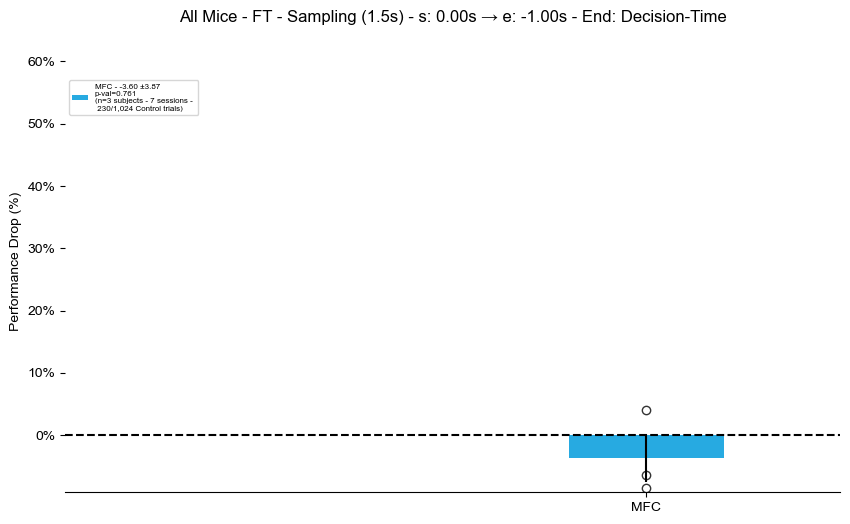

Series([], dtype: int64)

df_full_sampling: 0
df feedback: 0


Series([], dtype: int64)

In [ ]:
used_control_df = loopPlotOptoEffect(df_opto, applyFn=applyFnAll, single_subjects=False,
                                     save_prefix=save_prefix + "Performance_Control/", save_figs=True,
                                     only_control_animals=True,
                                     min_choice_trials=0,#20 if (_split_level == SplitLevelBy.Session) else 50,
                                )
used_control_df = used_control_df[0]

## Only two areas

In [ ]:
from .opto.optoprocessor import EffectSizeMetric, plotOptoEffect
from .opto.optoprocessor import SplitLevelBy
from .common.definitions import BrainRegion
from functools import partial


_split_level = SplitLevelBy.Animal
applyFn2Area = partial(plotOptoEffect, df_col_name="ChoiceCorrect",
                       split_level=_split_level,
                       mean_or_median="mean",
                       only_brain_regions=[BrainRegion.ALM_Bi, BrainRegion.M2_Bi],
                       #   only_brain_regions=[BrainRegion.ALM_Bi, BrainRegion.M2_Bi, BrainRegion.PPC_Bi, BrainRegion.RSP_Bi, BrainRegion.V1_Bi],
                       effect_size_metric=EffectSizeMetric.Gain,
                       # effect_size_metric=EffectSizeMetric.DistanceFromRandom, # CohenD
                       num_iterations=10_000,
                )
# New code at subject resample and trim_mean(.2)
used_early_late_ft_df = loopPlotOptoEffect(early_late_ft_df,
                                           applyFn=applyFn2Area, single_subjects=False,
                                           stim_type="FT",
                                           save_prefix=save_prefix + "Performance_bar/", save_figs=True,
                                           process_groups_together=True,
                                           # only_control_animals=True,
                                           min_choice_trials=30,#20 if (_split_level == SplitLevelBy.Session) else 50,
                                           )
used_early_late_ft_df = used_early_late_ft_df[0]

df_full_sampling: 0
df feedback: 0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.65                0.35             11.0               1.0               14.0                 16347
                     0.00                0.35             11.0               1.0               14.0                 15146
dtype: int64

Max ST Values:


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,31493.0,NaN,NaN,NaN,NaN
min,1.0,0.80000,0.000100,0.000400,2020-11-06
max,1.0,1.00000,1.035200,1.000200,2022-01-05
mean,1.0,0.99711,0.979429,0.974216,NaN


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,7089.0,NaN,NaN,NaN,NaN
min,1.0,0.810000,0.000100,0.000400,2020-11-06
max,1.0,1.000000,1.035200,1.000200,2022-01-05
mean,1.0,0.997134,0.965701,0.962514,NaN


...

Name     GUI_OptoBrainRegion  OptoCount  ControlCount  OptoAccept  ControlAccept
Avgat1   6.0                  38         157           True        True              195
                              59         262           True        True              321
         15.0                 90         298           True        True              388
Avgat2   6.0                  57         235           True        True              292
         15.0                 0          25            False       False              25
Avgat4   6.0                  42         194           True        True              236
BVAGT4   6.0                  51         349           True        True              400
                              67         230           True        True              297
         15.0                 42         216           True        True              258
                              106        481           True        True              587
BVGAT1   6.0                 

Num of Brain Regions: 2
********************* Check the next part carefully *********************


Name     OptoBrainRegion  Phase  OptoCount  ControlCount  ControlPerf  OptoPerf  OptoEffect
Avgat1   ALM              Early  38         157           0.758065     0.781250  -3.058511      195
                          Late   59         262           0.678295     0.711864  -4.949153      321
         M2               Early  90         298           0.771127     0.650602   15.629642     388
Avgat2   ALM              Early  57         235           0.732673     0.792453  -8.159102      292
Avgat4   ALM              Early  42         194           0.838150     0.815789   2.667877      236
BVAGT4   ALM              Early  67         230           0.804651     0.473684   41.131731     297
                          Late   51         349           0.758721     0.627451   17.301480     400
         M2               Early  106        481           0.807018     0.696970   13.636364     587
                          Late   42         216           0.823864     0.476190   42.200328     258
BVGAT1  

Bootstrap iterations:   0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 

# Reaction Time Distribution

In [ ]:
df_opto_fix.quantile_idx

0         1.0
1         1.0
2         1.0
3         1.0
4         1.0
         ... 
120251    3.0
120252    3.0
120253    3.0
120254    3.0
120255    1.0
Name: quantile_idx, Length: 119737, dtype: float64

df_full_sampling: 0
df feedback: 0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.3                 0.6              11.0               5.0               14.0                 49034
dtype: int64

Max ST Values:


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,49034.0,NaN,NaN,NaN,NaN
min,5.0,0.3000,0.000200,0.300400,2022-02-21
max,5.0,0.5000,4.988500,4.988500,2023-04-17
mean,5.0,0.3327,1.174196,1.201684,NaN


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,10017.0,NaN,NaN,NaN,NaN
min,5.0,0.300000,0.000700,0.303000,2022-02-21
max,5.0,0.500000,4.988500,4.988500,2023-04-17
mean,5.0,0.330828,1.252247,1.281983,NaN


Df len: 49034
TODO: **********TODO: Use min_choice_trials
Repeated Measures ANOVA Reaction-Time Results:
                 Anova
          F Value Num DF  Den DF Pr > F
---------------------------------------
Condition 14.1875 2.0000 12.0000 0.0007


Main effect of Condition: p = 0.0006893

Post-hoc pairwise comparisons (paired t-tests, Holm-corrected):
Control vs MFC: t=4.331, p_raw=0.004925, p_corr=0.01478, significant=True
Control vs LFC: t=3.557, p_raw=0.01197, p_corr=0.02394, significant=True
MFC vs LFC: t=-2.543, p_raw=0.04389, p_corr=0.04389, significant=True


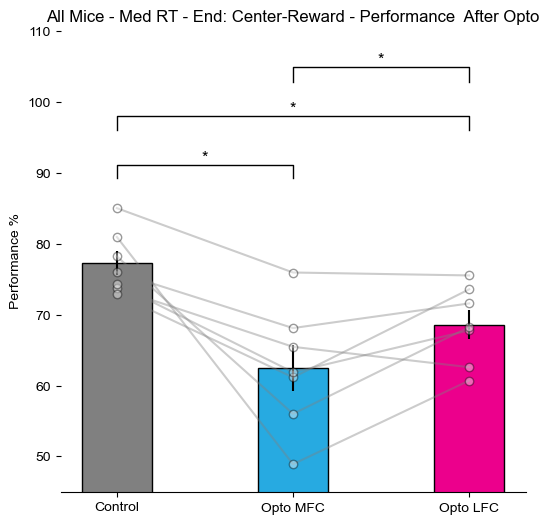

Repeated Measures ANOVA Reaction-Time Results:
                 Anova
          F Value Num DF  Den DF Pr > F
---------------------------------------
Condition  8.3667 2.0000 12.0000 0.0053


Main effect of Condition: p = 0.005306

Post-hoc pairwise comparisons (paired t-tests, Holm-corrected):
Control vs MFC: t=-3.774, p_raw=0.00925, p_corr=0.02775, significant=True
Control vs LFC: t=-1.331, p_raw=0.2314, p_corr=0.2314, significant=False
MFC vs LFC: t=3.162, p_raw=0.01953, p_corr=0.03905, significant=True


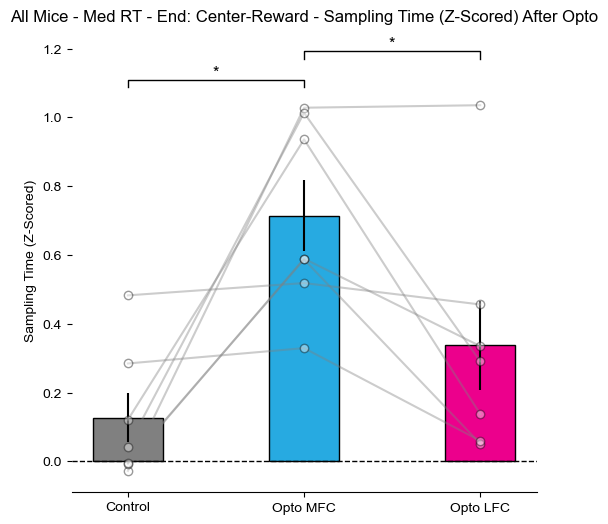

Perfs vals: (array([71.09634551, 64.86486486, 71.75398633, 74.94145199, 71.50537634,
       71.37840211, 78.30802603]), array([78.57142857, 52.38095238, 50.        , 55.26315789, 53.84615385,
       53.84615385]), array([54.26356589, 50.        , 72.72727273, 57.89473684, 62.44131455,
       63.26530612, 64.62264151]), array([87.1559633 , 79.12713472, 77.01711491, 74.06542056, 72.93064877,
       76.40264026, 79.91803279]), array([77.5       , 50.4950495 , 67.72151899, 65.47619048, 61.94968553,
       62.72040302, 55.97269625]), array([81.08108108, 59.65909091, 71.07438017, 62.5       , 72.07207207,
       68.86792453, 70.75471698]))


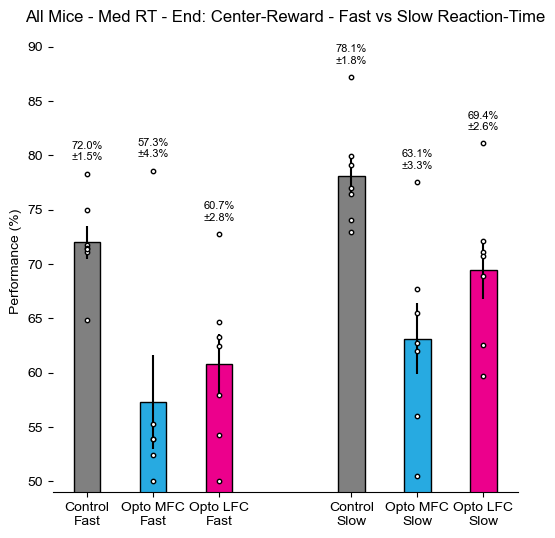

c:\Users\float\OneDrive\caiman\paper_fast_slow\code\opto\optoreactiontime.py:391: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for animal_name, animal_df in df.groupby(["Name",


,Name,RT,NumTrials,RewardRate,Group
0,BVGAT1,-0.752791,24,0.0,Control
12,BVGAT3,0.218104,30,0.0,Control
24,BVGAT5,0.520623,17,0.0,Control
36,vgat-40,-0.076019,28,0.0,Control
48,vgat-46,0.086006,50,0.0,Control
...,...,...,...,...,...
31,BVGAT5,0.197968,52,1.0,MFC
43,vgat-40,0.044463,20,1.0,MFC
55,vgat-46,0.063739,84,1.0,MFC
67,vgat-94,-0.129480,108,1.0,MFC


c:\Users\float\OneDrive\caiman\paper_fast_slow\code\opto\optoreactiontime.py:1033: RuntimeWarning: Mean of empty slice.
  arr_mean = arr.mean()
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


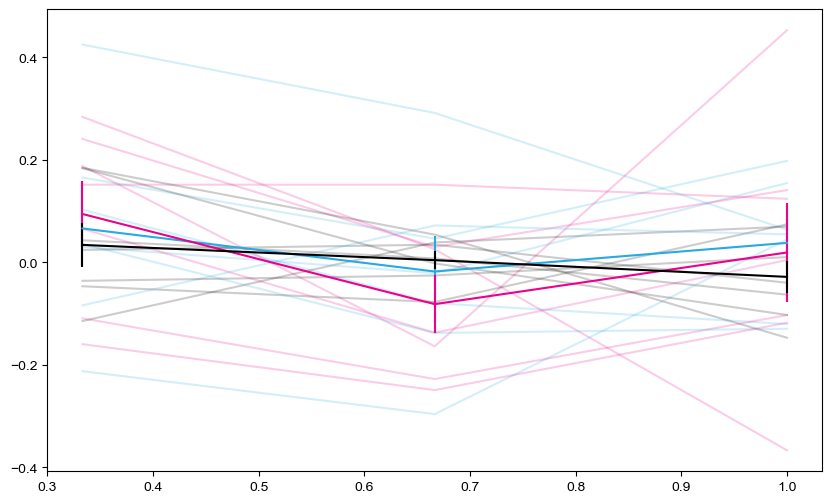

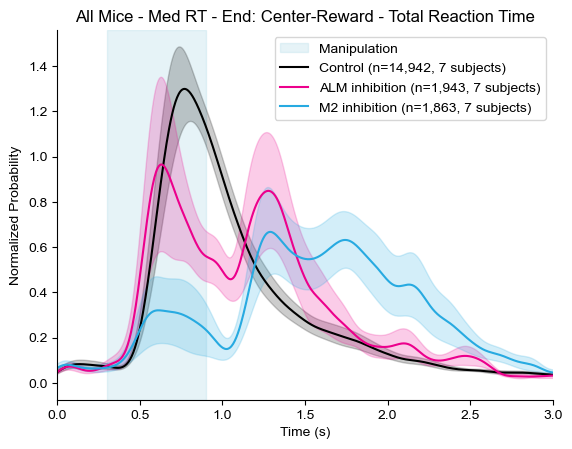

c:\Users\float\OneDrive\caiman\paper_fast_slow\code\opto\optoreactiontime.py:1033: RuntimeWarning: Mean of empty slice.
  arr_mean = arr.mean()
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


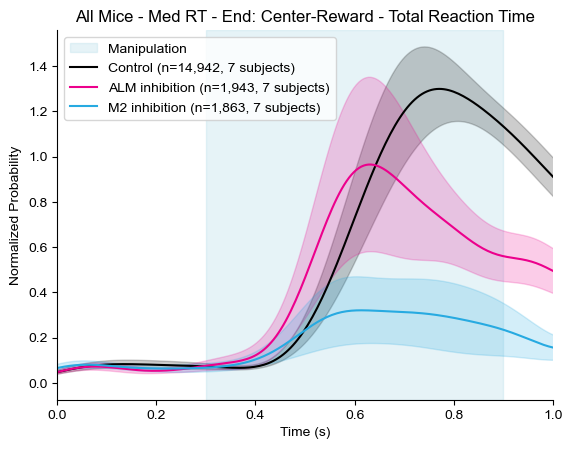

c:\Users\float\OneDrive\caiman\paper_fast_slow\code\opto\optoreactiontime.py:1033: RuntimeWarning: Mean of empty slice.
  arr_mean = arr.mean()
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


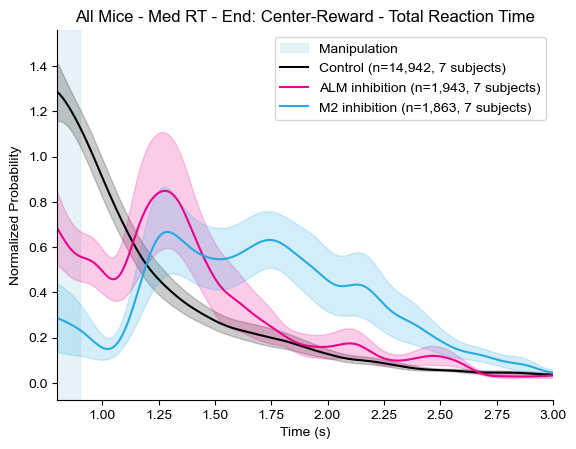

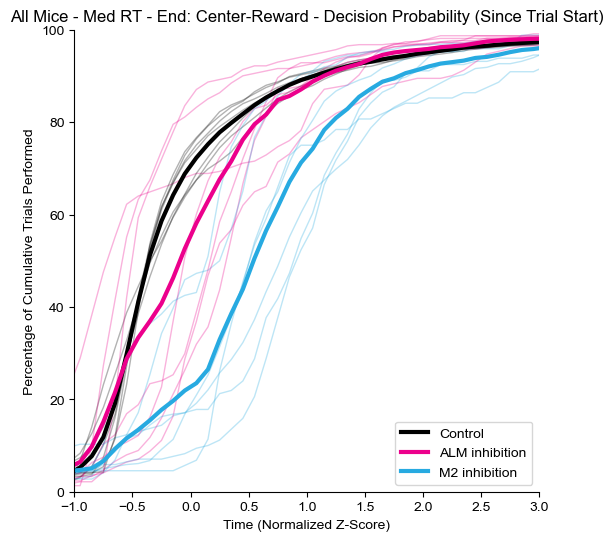

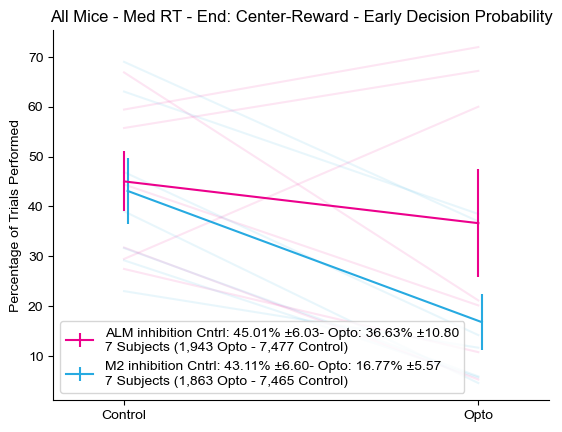

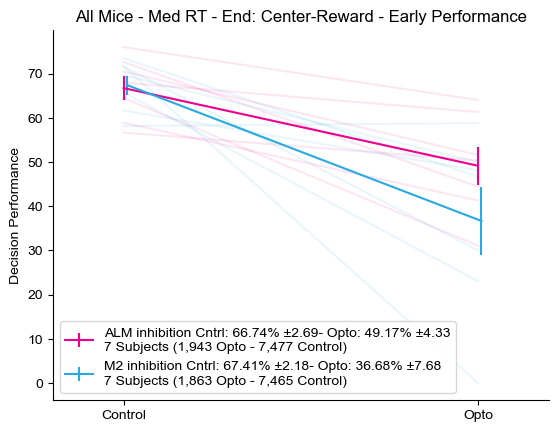

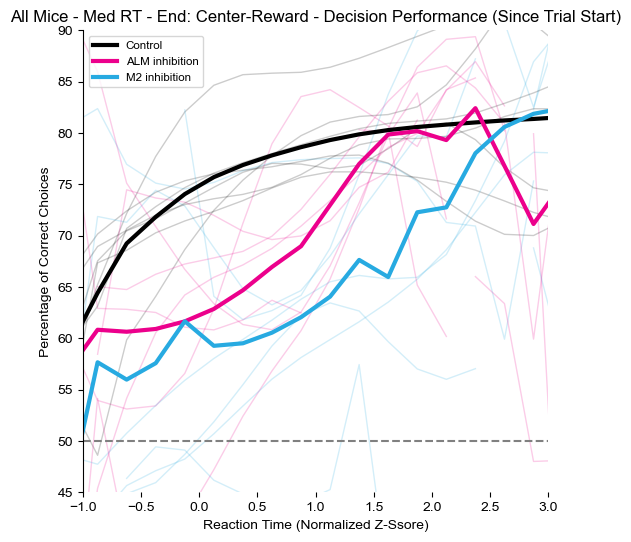

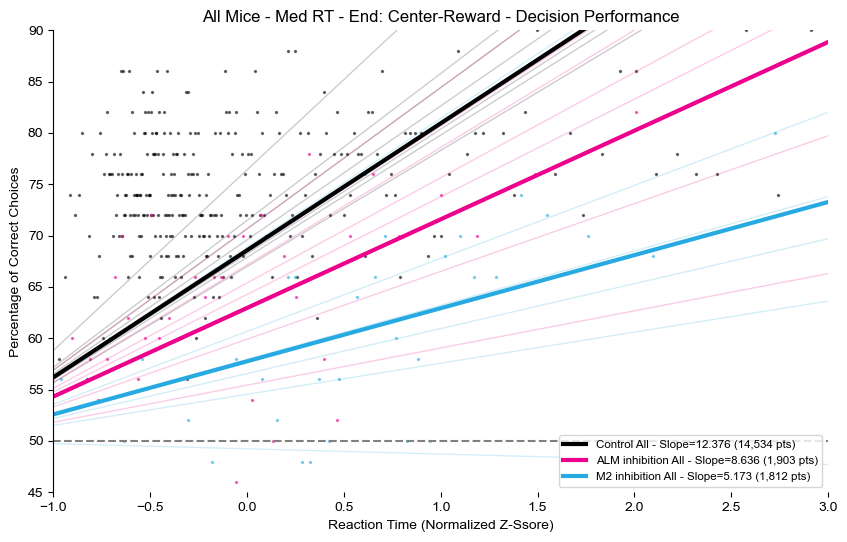

In [ ]:
from .opto.optoreactiontime import optoReactionTime
from .common.definitions import BrainRegion, MatrixState
from .opto.optoprocessor import SplitLevelBy
from functools import partial

applyFn = partial(optoReactionTime, z_score=True, plot_sem=False,
                  # split_level=SplitLevelBy.AllAnimals,
                  only_brain_regions=[BrainRegion.ALM_Bi, BrainRegion.M2_Bi], )

used_rt_df = loopPlotOptoEffect(df_opto_fix.query("abs(GUI_OptoStartDelay - 0.3) < 0.001 and "
                                                  "abs(GUI_OptoMaxTime - 0.6) < 0.001 and "
                                                  f"GUI_OptoStartState1 == {int(MatrixState.stimulus_delivery)}"),
                                applyFn=applyFn, single_subjects=False,
                                save_prefix=save_prefix + "/RT/", save_figs=True,
                                stim_type="RT",
                                min_choice_trials=30,
                                )
used_rt_df = used_rt_df[0]

# Opto Feedback

df_full_sampling: 0
df feedback: 15757
Df len: 15757
Start state: WaitForReward
TODO: **********TODO: Use min_choice_trials

--- Within-Condition (Correct vs Incorrect) ---
Cntrl: t=-2.08, p_raw=0.1296, p_holm=0.2591
Opto_MFC: t=-0.67, p_raw=0.5534, p_holm=0.5534
Opto_LFC: t=-3.08, p_raw=0.0542, p_holm=0.1627

--- Cross-Region Correct (RM ANOVA) ---
               Anova
       F Value Num DF Den DF Pr > F
-----------------------------------
Region 29.1506 2.0000 6.0000 0.0008

--- Pairwise Correct (Holm) ---
Cntrl vs Opto_MFC: t=-6.54, p_holm=0.0218
Cntrl vs Opto_LFC: t=0.87, p_holm=0.4495
Opto_MFC vs Opto_LFC: t=6.07, p_holm=0.0218

--- Cross-Region Incorrect (RM ANOVA) ---
               Anova
       F Value Num DF Den DF Pr > F
-----------------------------------
Region  5.9792 2.0000 6.0000 0.0373

--- Pairwise Incorrect (Holm) ---
Cntrl vs Opto_MFC: t=-2.72, p_holm=0.2176
Cntrl vs Opto_LFC: t=0.18, p_holm=0.8701
Opto_MFC vs Opto_LFC: t=2.41, p_holm=0.2176


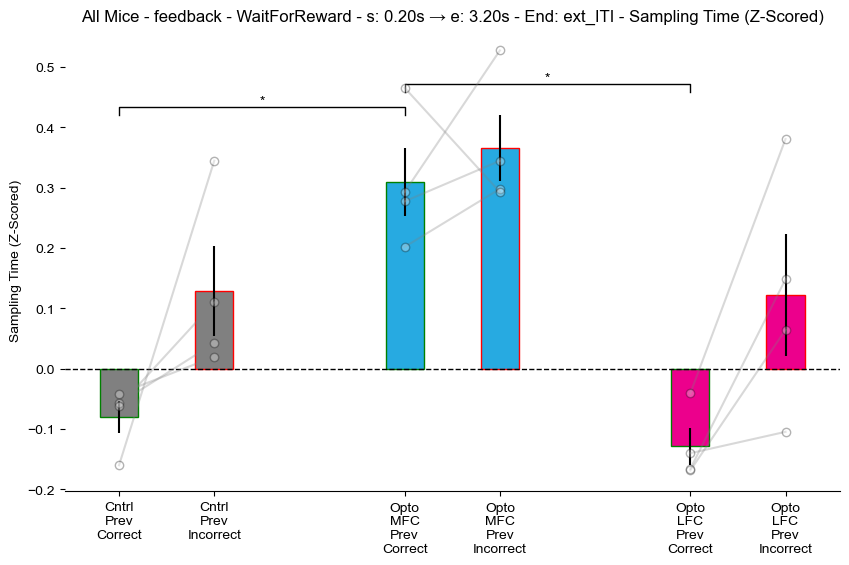

df_full_sampling: 0
df feedback: 15757
Df len: 15757
Start state: WaitForReward
TODO: **********TODO: Use min_choice_trials

--- Within-Condition (Correct vs Incorrect) ---
Cntrl_MFC: t=-2.68, p_raw=0.0750, p_holm=0.2249
Opto_MFC: t=-0.67, p_raw=0.5534, p_holm=0.5534
Cntrl_LFC: t=-1.37, p_raw=0.2639, p_holm=0.5279
Opto_LFC: t=-3.08, p_raw=0.0542, p_holm=0.2170

--- Cross-Region Correct (RM ANOVA) ---
               Anova
       F Value Num DF Den DF Pr > F
-----------------------------------
Region 23.6929 3.0000 9.0000 0.0001

--- Pairwise Correct (Holm) ---
Cntrl_MFC vs Opto_MFC: t=-5.29, p_holm=0.0547
Cntrl_MFC vs Cntrl_LFC: t=4.06, p_holm=0.0809
Cntrl_MFC vs Opto_LFC: t=2.33, p_holm=0.1018
Opto_MFC vs Cntrl_LFC: t=5.66, p_holm=0.0547
Opto_MFC vs Opto_LFC: t=6.07, p_holm=0.0537
Cntrl_LFC vs Opto_LFC: t=-3.34, p_holm=0.0889

--- Cross-Region Incorrect (RM ANOVA) ---
               Anova
       F Value Num DF Den DF Pr > F
-----------------------------------
Region 11.2350 3.0000 9.00

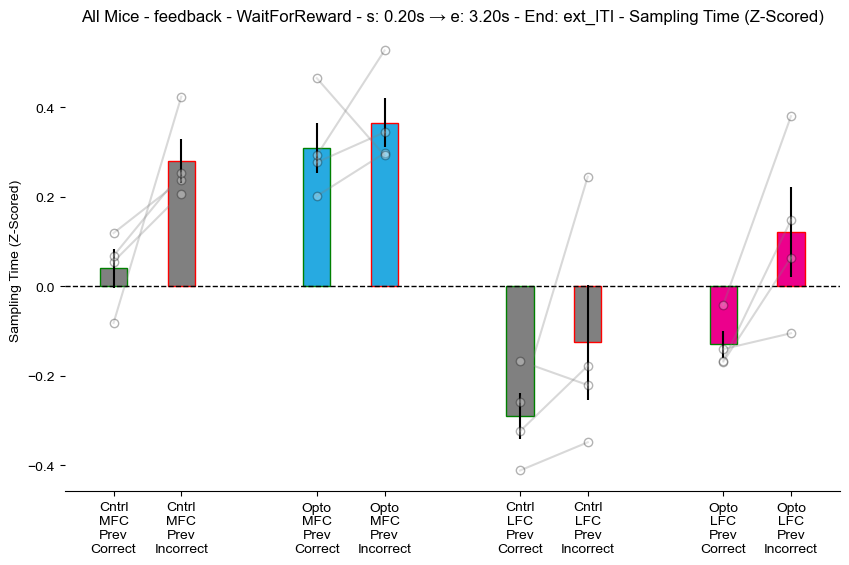

In [ ]:
from .opto.optofeedback import optoFeedback
from .common.definitions import BrainRegion, MatrixState
from .opto.optoprocessor import SplitLevelBy
from functools import partial


def runFeedbackOptoAnalysis(df_opto_feedback, combine_control, z_score,
                            z_score_how : Literal["Subject", "Session"],
                            plot_as_difference : bool):
    applyFn = partial(optoFeedback, z_score=z_score, z_score_how=z_score_how,
                      combine_control=combine_control, plot_sem=False,
                      # split_level=SplitLevelBy.AllAnimals,
                      only_brain_regions=[BrainRegion.ALM_Bi, BrainRegion.M2_Bi],
                      plot_as_difference=plot_as_difference,
                      num_iterations=10_000,
                    #   num_iterations=50,
                      )

    used_rt_df = loopPlotOptoEffect(df_opto_feedback,
                                    applyFn=applyFn, single_subjects=False,
                                    stim_type="feedback",
                                    min_choice_trials=30,
                                    save_prefix=save_prefix + "/feedback/",
                                    save_figs=False,
                                    )
    used_rt_df = used_rt_df[0]
    return used_rt_df

z_score_how="Subject"
# z_score_how="Session"
# runFeedbackOptoAnalysis(df_opto_feedback, combine_control=True, z_score=True,
#                         z_score_how=z_score_how, plot_as_difference=True)
# runFeedbackOptoAnalysis(df_opto_feedback, combine_control=False, z_score=True,
#                         z_score_how=z_score_how, plot_as_difference=True)

runFeedbackOptoAnalysis(df_opto_feedback, combine_control=True, z_score=True,
                        z_score_how=z_score_how, plot_as_difference=False)
runFeedbackOptoAnalysis(df_opto_feedback, combine_control=False, z_score=True,
                        z_score_how=z_score_how, plot_as_difference=False)
None

In [ ]:
display(df_col_name = "WithinOptoFiring"[_med_rt_df.quantile_idx == 1][["Name", "GUI_OptoBrainRegion"]].value_counts().sort_index())
display(_med_rt_df[_med_rt_df.quantile_idx == 3][["Name", "GUI_OptoBrainRegion"]].value_counts().sort_index())

Name     GUI_OptoBrainRegion
BVAGT4   6.0                     316
         15.0                    203
BVGAT1   6.0                     349
         15.0                    151
BVGAT2   6.0                      11
BVGAT3   6.0                     375
         15.0                    232
BVGAT5   6.0                     232
         15.0                    237
vgat-40  5.0                      72
         6.0                     390
         14.0                    118
         15.0                    948
         100.0                  2059
vgat-46  5.0                     344
         6.0                     705
         14.0                    186
         15.0                    555
         100.0                  2006
vgat-94  5.0                     360
         6.0                     660
         14.0                    241
         15.0                    704
         100.0                  2045
vgat-95  6.0                      23
         15.0                      3
vgat-96  

Name     GUI_OptoBrainRegion
BVAGT4   6.0                     317
         15.0                    201
BVGAT1   6.0                     287
         15.0                    256
BVGAT2   6.0                      14
BVGAT3   6.0                     550
         15.0                    309
BVGAT5   6.0                     346
         15.0                    389
vgat-40  5.0                      45
         6.0                     461
         14.0                    136
         15.0                   1053
         100.0                  2141
vgat-46  5.0                     298
         6.0                     608
         14.0                    211
         15.0                    850
         100.0                  2009
vgat-94  5.0                     378
         6.0                     794
         14.0                    362
         15.0                   1099
         100.0                  2145
vgat-95  6.0                      15
         15.0                     13
vgat-96  

In [ ]:
# Test Fast/Slow

from .opto.optoprocessor import EffectSizeMetric, plotOptoEffect
from .opto.optoprocessor import SplitLevelBy
from .common.definitions import BrainRegion
from functools import partial


_split_level = SplitLevelBy.Animal

applyFn = partial(plotOptoEffect,
                  #   df_col_name="ChoiceCorrect",
                  split_level=_split_level,
                  mean_or_median="mean",
                  only_brain_regions=[BrainRegion.ALM_Bi, BrainRegion.M2_Bi],
                #   only_brain_regions=[BrainRegion.ALM_Bi, BrainRegion.M2_Bi, BrainRegion.PPC_Bi, BrainRegion.RSP_Bi, BrainRegion.V1_Bi],
                  effect_size_metric=EffectSizeMetric.Gain,
                  # effect_size_metric=EffectSizeMetric.DistanceFromRandom, # CohenD
                  num_iterations=10_000,
                )

_med_rt_df = df_opto_fix.query("abs(GUI_OptoStartDelay - 0.3) < 0.001 and "
                               "abs(GUI_OptoMaxTime - 0.6) < 0.001 and "
                               f"GUI_OptoStartState1 == {int(MatrixState.stimulus_delivery)}").copy()


# def _calcWithinLastQuantile(sess_df):
#     slow_cntrl = sess_df[(sess_df.OptoEnabled == 0)] # & (sess_df.quantile_idx == 3)]
#     slow_cntrl_90th_pct = slow_cntrl.calcStimulusTime.quantile(0.9)
#     print(f"Sess {sess_df.Name.iloc[0]} - slow cntrl 90th pct: {slow_cntrl_90th_pct:.3f}")
#     sess_df["withinLastQuantile"] = sess_df.calcStimulusTime > 4 #slow_cntrl_90th_pct
#     return sess_df

# _med_rt_df = _med_rt_df.groupby(["Name", "Date", "SessionNum"] if _split_level == SplitLevelBy.Session else ["Name"],
#                                 group_keys=False).apply(_calcWithinLastQuantile)
# _med_rt_df["WithinOptoFiring"] = _med_rt_df.calcStimulusTime <= _med_rt_df.GUI_OptoStartDelay + _med_rt_df.GUI_OptoMaxTime
# display(_med_rt_df[["Name", "GUI_OptoBrainRegion", "quantile_idx", "WithinOptoFiring"]].value_counts().sort_index())

# _kw_args = dict(#applyFn=applyFn,
#                 single_subjects=False,
#                 save_prefix=save_prefix + "Performance/", save_figs=False,
#                 # only_control_animals=True,
#                 min_choice_trials=10, # For the 3 quantiles it's 30
#                 )

# # loopPlotOptoEffect(_med_rt_df[_med_rt_df.quantile_idx == 1], partial(applyFn, df_col_name="WithinOptoFiring"), **_kw_args)
# loopPlotOptoEffect(_med_rt_df[_med_rt_df.quantile_idx == 3], partial(applyFn, df_col_name="withinLastQuantile"), **_kw_args)


## Fast-Slow

# Psychometric

In [ ]:
from .opto.optoprocessor import plotOptoPsych, SplitLevelBy
from functools import partial

applyFn = partial(plotOptoPsych,  split_level=SplitLevelBy.AllAnimals)
common_kwargs = dict(applyFn=applyFn, single_subjects=False,
                     save_figs=True,
                    )

df_full_sampling: 20602
End State: 11.0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.0                 1.0              11.0               1.0               14.0                 20602
dtype: int64

,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,20602.0,NaN,NaN,NaN,NaN
min,1.0,0.800000,0.000100,0.000100,2020-10-02
max,1.0,1.000000,1.035200,1.000200,2021-12-26
mean,1.0,0.995538,0.964706,0.966139,NaN


Start state: Sampling
Control Trials: 3088
Opto Trials: 1126
Plotting overall psychometric
Mean: 57.77777777777777 - SEM: nan - len(perf_col): 1
Mean: 53.333333333333336 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Plotting overall psychometric
Mean: 64.28571428571429 - SEM: nan - len(perf_col): 1
Mean: 73.33333333333333 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


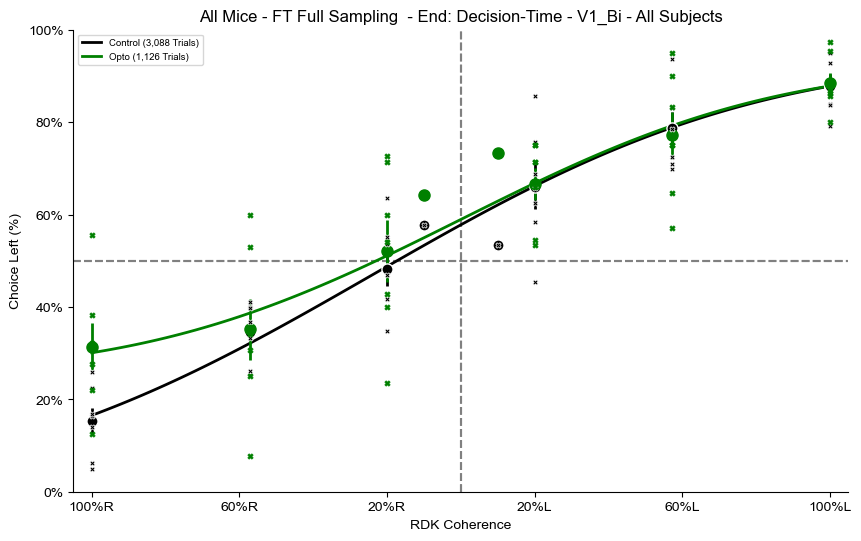

Control Trials: 4859
Opto Trials: 1503
Plotting overall psychometric
Plotting overall psychometric


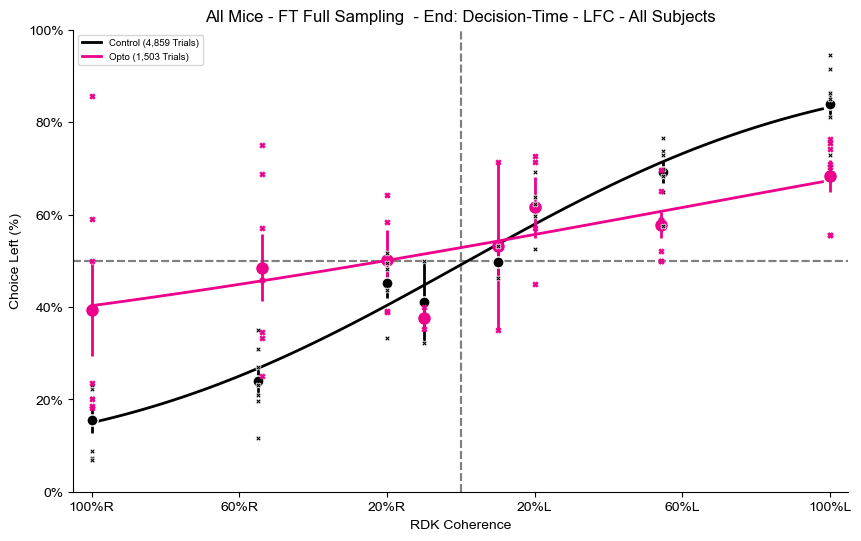

Control Trials: 2131
Opto Trials: 719
Plotting overall psychometric
Plotting overall psychometric
Mean: 100.0 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


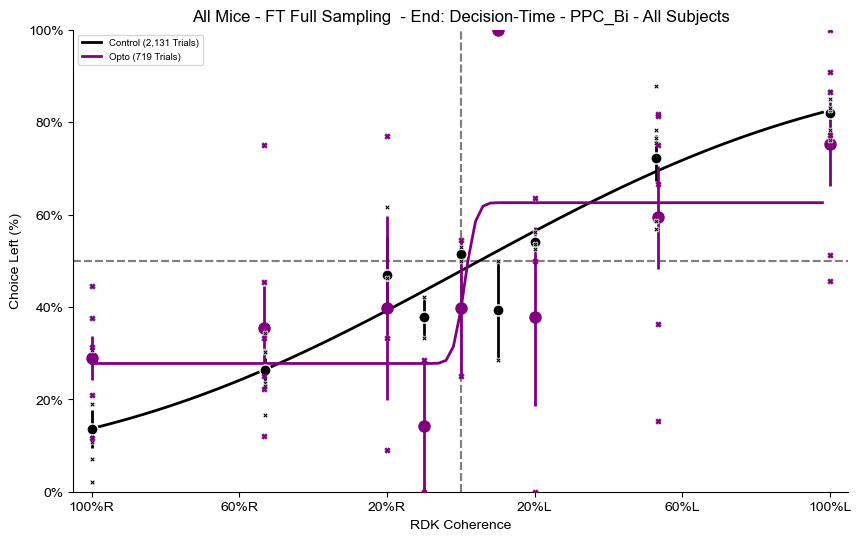

Control Trials: 3704
Opto Trials: 1018
Plotting overall psychometric
Mean: 38.775510204081634 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Plotting overall psychometric
Mean: 71.42857142857143 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


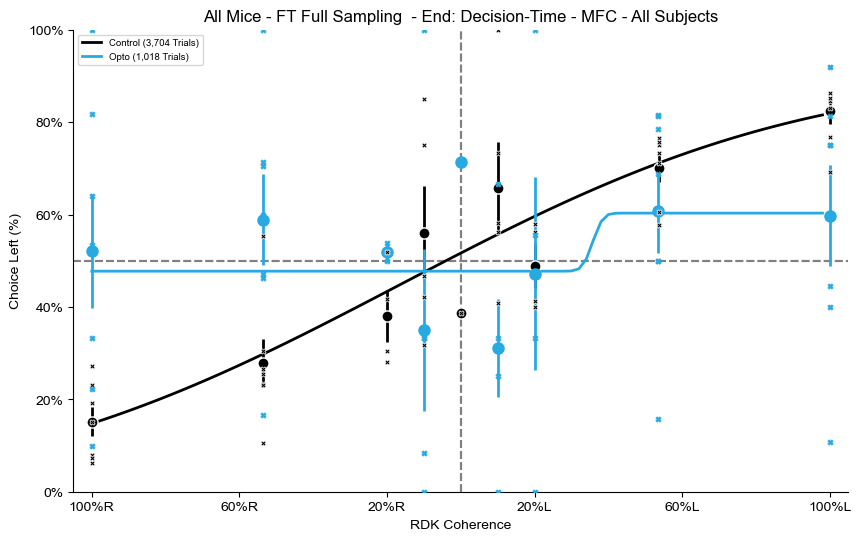

Control Trials: 1719
Opto Trials: 735
Plotting overall psychometric
Mean: 83.33333333333334 - SEM: nan - len(perf_col): 1
Mean: 72.72727272727273 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Plotting overall psychometric
Mean: 16.666666666666664 - SEM: nan - len(perf_col): 1
Mean: 50.0 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


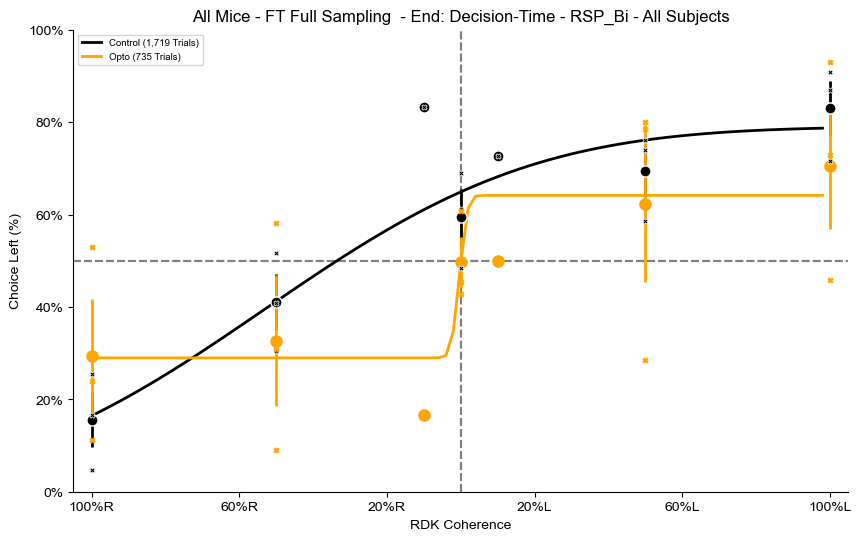

Series([], dtype: int64)

df_full_sampling: 0


Series([], dtype: int64)

[None]

In [ ]:
loopPlotOptoEffect(used_full_ft_df,
                   min_choice_trials=30,
                   save_prefix=save_prefix + "Psychometric/full_ft/",
                   **common_kwargs)

,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,1254.0,NaN,NaN,NaN,NaN
min,1.5,1.0,0.000900,0.990300,2022-10-02
max,1.5,1.0,1.971200,1.971200,2022-10-16
mean,1.5,1.0,1.393895,1.459793,NaN


Name  GUI_OptoBrainRegion
WF10  15.0                   660
WF13  15.0                   449
WF14  15.0                   145
dtype: int64

df_full_sampling: 1254
End State: 11.0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.0                 1.5              11.0               1.5               14.0                 1254
dtype: int64

,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,1254.0,NaN,NaN,NaN,NaN
min,1.5,1.0,0.000900,0.990300,2022-10-02
max,1.5,1.0,1.971200,1.971200,2022-10-16
mean,1.5,1.0,1.393895,1.459793,NaN


Start state: Sampling (1.5s)
Control Trials: 1024
Opto Trials: 230
Plotting overall psychometric
Mean: 25.806451612903224 - SEM: nan - len(perf_col): 1
Mean: 62.857142857142854 - SEM: nan - len(perf_col): 1
Mean: 66.66666666666666 - SEM: nan - len(perf_col): 1
Mean: 89.28571428571429 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in s

Plotting overall psychometric
Mean: 50.0 - SEM: nan - len(perf_col): 1
Mean: 66.66666666666666 - SEM: nan - len(perf_col): 1
Mean: 0.0 - SEM: nan - len(perf_col): 1
Mean: 75.0 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in s

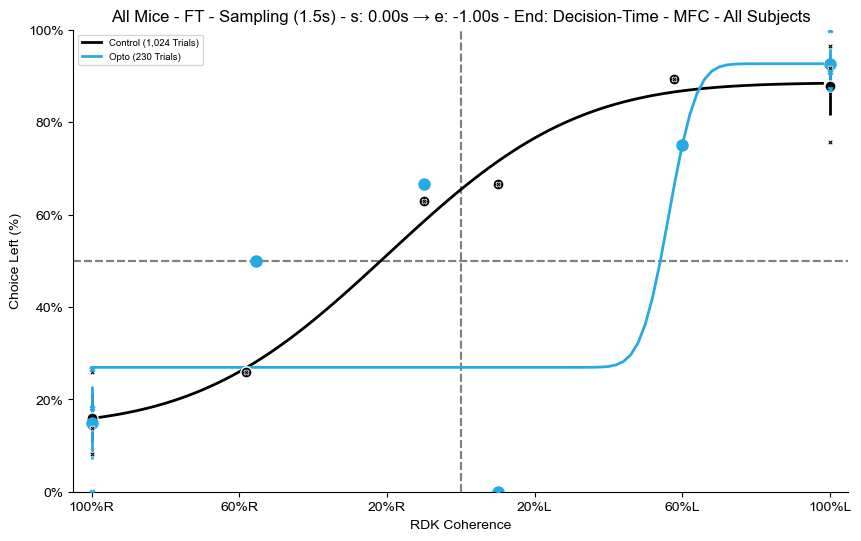

Series([], dtype: int64)

df_full_sampling: 0


Series([], dtype: int64)

[None]

In [ ]:
loopPlotOptoEffect(used_control_df,
                   min_choice_trials=0,
                   only_control_animals=True,
                   save_prefix=save_prefix + "Psychometric/control/",
                   **common_kwargs)

Early trials: 10484, Late trials: 10965
df_full_sampling: 0
df feedback: 0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.0                 0.35             11.0               1.0               14.0                 10394
dtype: int64

Max ST Values:


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,10394.0,NaN,NaN,NaN,NaN
min,1.0,0.800000,0.000100,0.002000,2020-11-09
max,1.0,1.000000,1.029700,1.000200,2021-12-23
mean,1.0,0.997321,0.969535,0.972181,NaN


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,2354.0,NaN,NaN,NaN,NaN
min,1.0,0.810000,0.000100,0.002000,2020-11-09
max,1.0,1.000000,1.029700,1.000200,2021-12-23
mean,1.0,0.997782,0.932131,0.945628,NaN


Start state: Sampling
Control Trials: 3861
Opto Trials: 1279
Plotting overall psychometric
Mean: 100.0 - SEM: nan - len(perf_col): 1
Mean: 66.66666666666666 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Plotting overall psychometric
Mean: 100.0 - SEM: nan - len(perf_col): 1
Mean: 33.33333333333333 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


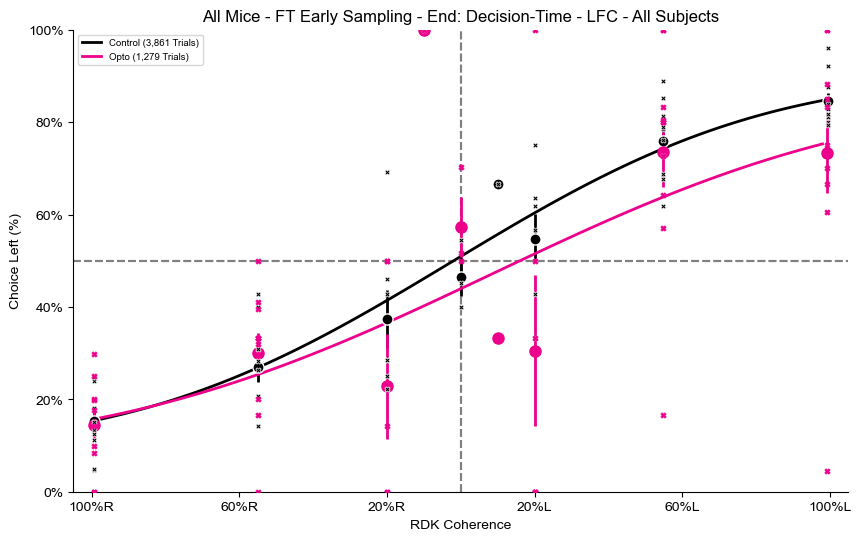

Control Trials: 4179
Opto Trials: 1075
Plotting overall psychometric
Plotting overall psychometric


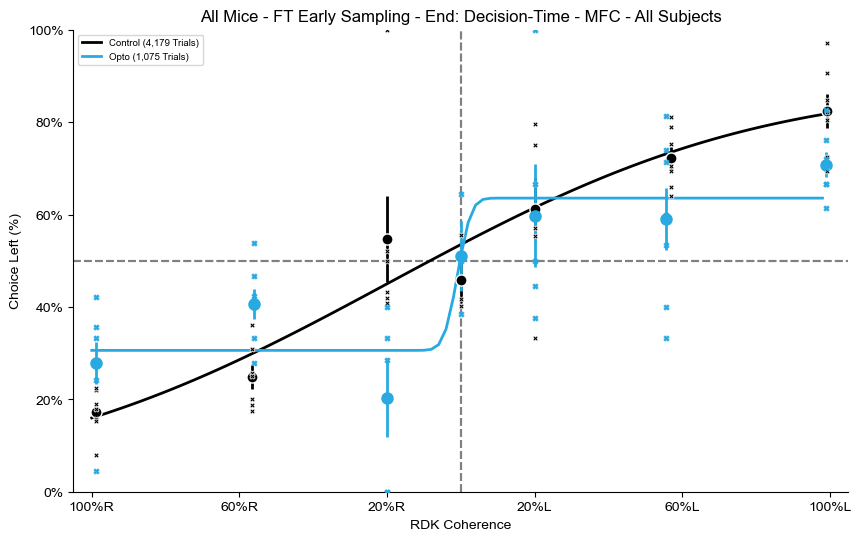

df_full_sampling: 0
df feedback: 0


Series([], dtype: int64)

df_full_sampling: 0
df feedback: 0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.65                0.35             11.0               1.0               14.0                 10780
dtype: int64

Max ST Values:


...

,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,2189.0,NaN,NaN,NaN,NaN
min,1.0,0.840000,0.0068,0.006800,2020-11-12
max,1.0,1.000000,1.0297,1.000200,2021-12-23
mean,1.0,0.997346,0.9921,0.980014,NaN


Start state: Sampling
Control Trials: 4461
Opto Trials: 997
Plotting overall psychometric
Mean: 61.53846153846154 - SEM: nan - len(perf_col): 1
Mean: 62.5 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Plotting overall psychometric
Mean: 25.0 - SEM: nan - len(perf_col): 1
Mean: 75.0 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


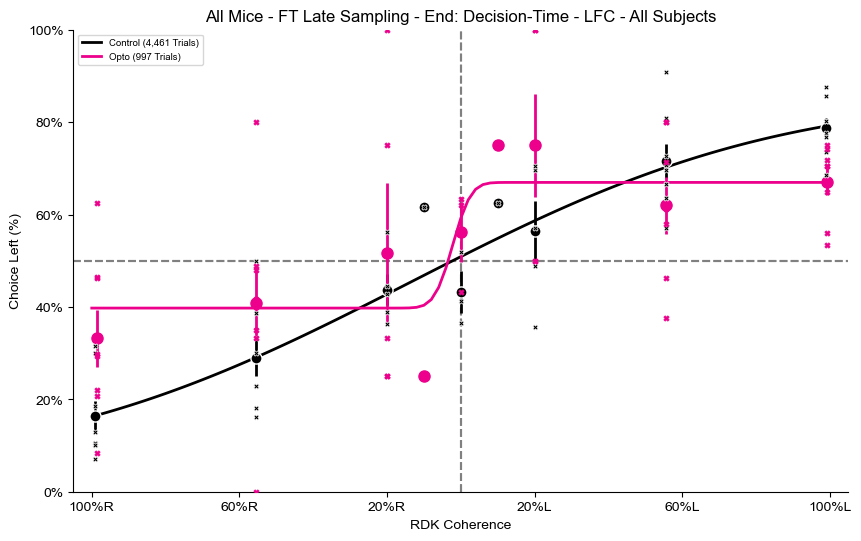

Control Trials: 4130
Opto Trials: 1192
Plotting overall psychometric
Plotting overall psychometric


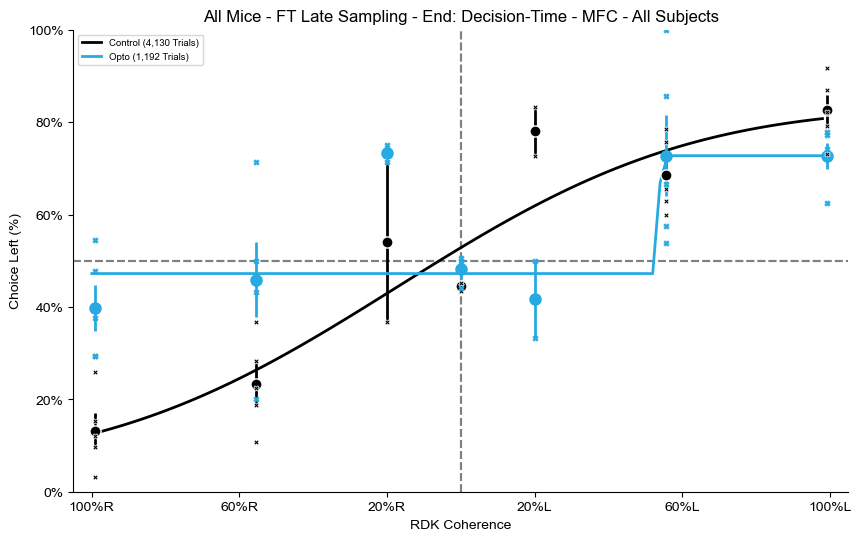

df_full_sampling: 0
df feedback: 0


Series([], dtype: int64)

In [ ]:
def saveEarlyLate():
    used_early_df = used_early_late_ft_df[used_early_late_ft_df.GUI_OptoStartDelay == 0]
    used_late_df = used_early_late_ft_df[used_early_late_ft_df.GUI_OptoStartDelay >= 0.5]
    print(f"Early trials: {len(used_early_df)}, Late trials: {len(used_late_df)}")
    loopPlotOptoEffect(used_early_df,
                       min_choice_trials=30,
                       save_prefix=save_prefix + "Psychometric/early_ft",
                      **common_kwargs)
    loopPlotOptoEffect(used_late_df,
                       min_choice_trials=30,
                       save_prefix=save_prefix + "Psychometric/late_ft",
                      **common_kwargs)

saveEarlyLate()

df_full_sampling: 0


Series([], dtype: int64)

df_full_sampling: 0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.3                 0.6              11.0               5.0               14.0                 18363
dtype: int64

Max ST Values:


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,18363.0,NaN,NaN,NaN,NaN
min,5.0,0.300000,0.000200,0.300400,2022-02-21
max,5.0,0.500000,4.895700,4.895700,2023-03-13
mean,5.0,0.311011,1.213376,1.244743,NaN


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,3806.0,NaN,NaN,NaN,NaN
min,5.0,0.300000,0.001500,0.303800,2022-02-21
max,5.0,0.500000,4.895700,4.895700,2023-03-13
mean,5.0,0.309879,1.403113,1.435765,NaN


Control Trials: 7291
Opto Trials: 1943
Plotting overall psychometric
Plotting overall psychometric


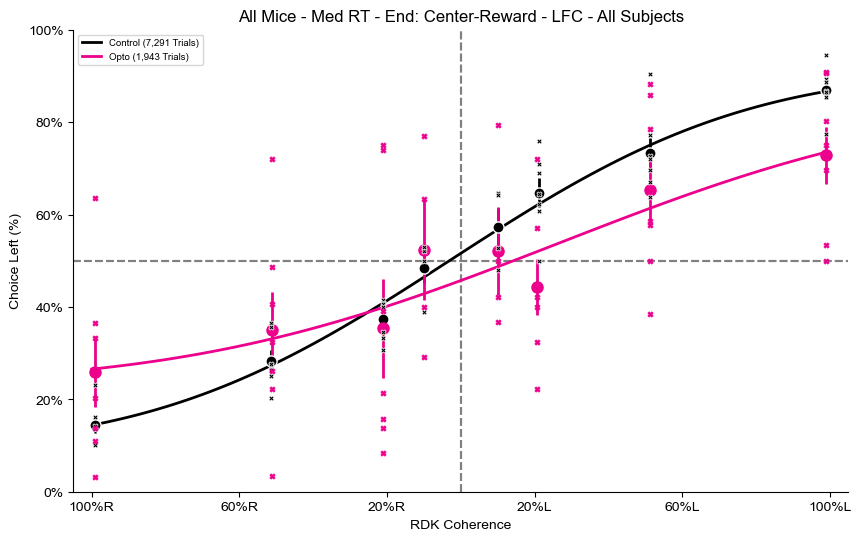

Control Trials: 7266
Opto Trials: 1863
Plotting overall psychometric
Plotting overall psychometric


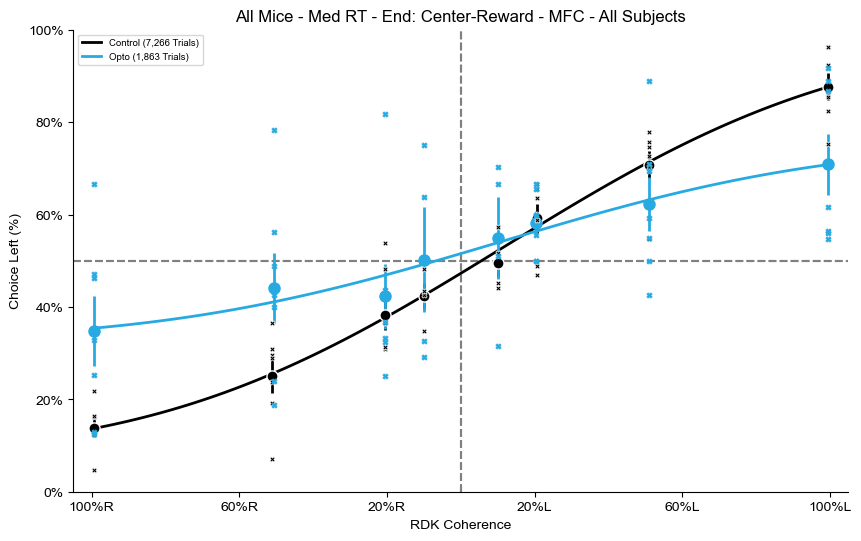

[None]

In [ ]:
loopPlotOptoEffect(used_rt_df,
                   min_choice_trials=30,
                   save_prefix=save_prefix + "Psychometric/free_sampling/",
                   **common_kwargs)

## Old psych where we put all together

df_full_sampling: 0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.3                 0.6              11.0               5.0               14.0                 50948
dtype: int64

Max ST Values:


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,50948.0,NaN,NaN,NaN,NaN
min,5.0,0.300000,0.000200,0.300400,2022-02-21
max,5.0,0.500000,4.988500,4.988500,2023-04-17
mean,5.0,0.332606,1.178417,1.206911,NaN


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,10237.0,NaN,NaN,NaN,NaN
min,5.0,0.300000,0.000700,0.303000,2022-02-21
max,5.0,0.500000,4.988500,4.988500,2023-04-17
mean,5.0,0.330439,1.259612,1.291038,NaN


Mean: 45.45454545454545 - SEM: nan - len(perf_col): 1
Mean: 75.0 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in s

Mean: 20.0 - SEM: nan - len(perf_col): 1
Mean: 50.0 - SEM: nan - len(perf_col): 1


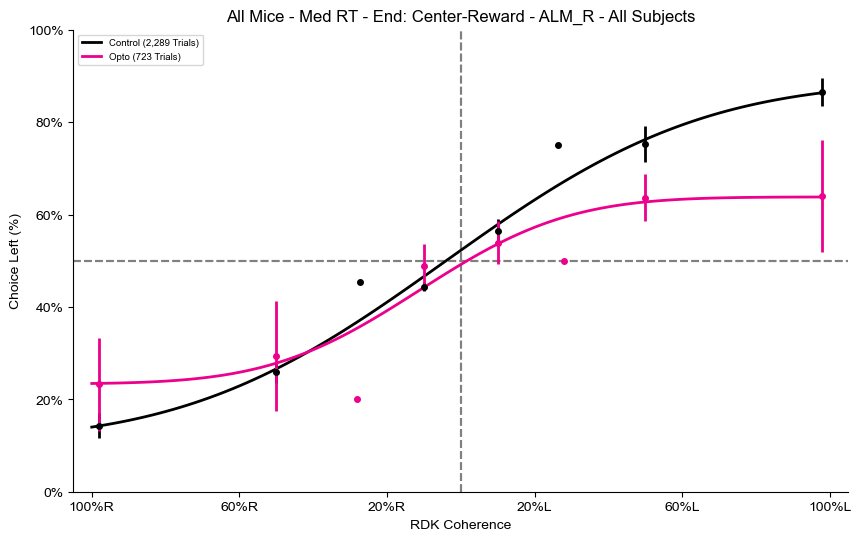

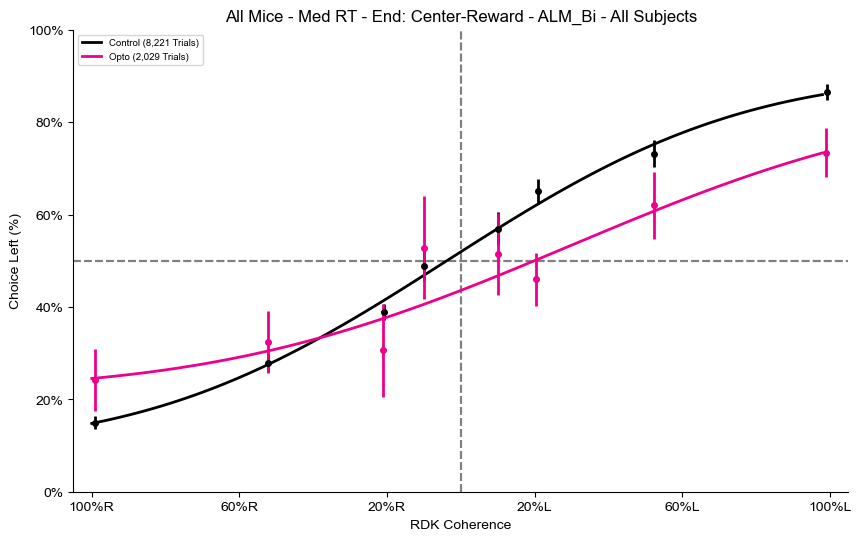

c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mean: 23.52941176470588 - SEM: nan - len(perf_col): 1
Mean: 67.64705882352942 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mean: 25.0 - SEM: nan - len(perf_col): 1
Mean: 20.0 - SEM: nan - len(perf_col): 1


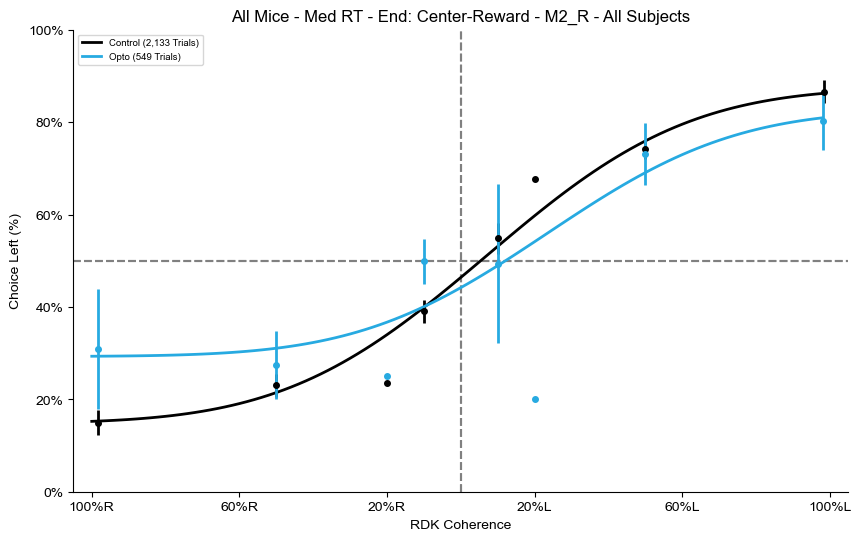

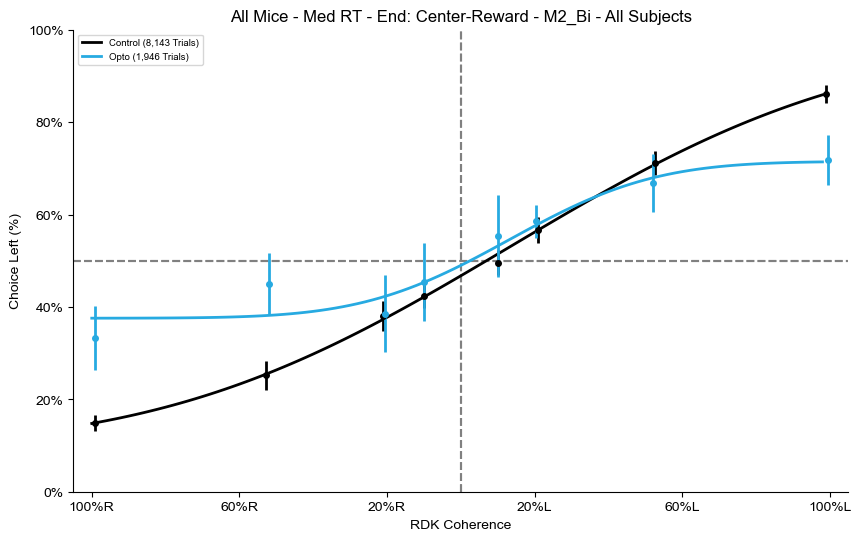

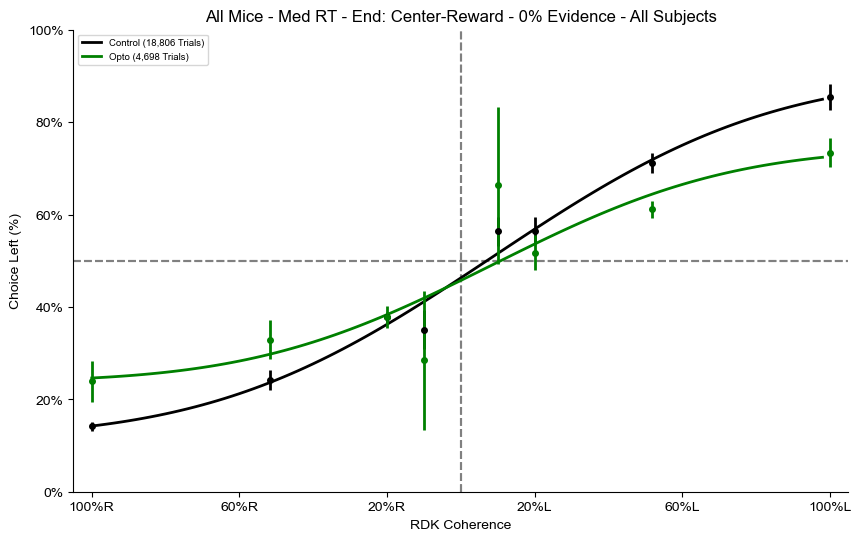

In [ ]:
loopPlotOptoEffect(df_opto,  stim_type="RT", which="all",
                   **common_kwargs,
                   )


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,7802.0,NaN,NaN,NaN,NaN
min,5.0,0.300000,0.000200,0.301000,2023-06-22
max,5.0,0.500000,24.799800,4.982500,2023-07-23
mean,5.0,0.414278,1.675708,1.311582,NaN


Name   GUI_OptoBrainRegion
YWF-6  100.0                  2355
YWD-4  15.0                   2348
       100.0                  2110
YWF-6  15.0                    989
dtype: int64

df_full_sampling: 0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.3                 0.6              11.0               5.0               14.0                 7031
                                         0.9              11.0               5.0               14.0                  515
dtype: int64

Max ST Values:


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,7031.0,NaN,NaN,NaN,NaN
min,5.0,0.30000,0.000200,0.301000,2023-06-22
max,5.0,0.50000,24.694600,4.982500,2023-07-23
mean,5.0,0.40559,1.686213,1.318177,NaN


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,1962.0,NaN,NaN,NaN,NaN
min,5.0,0.300000,0.006800,0.301000,2023-06-22
max,5.0,0.500000,18.023100,4.982500,2023-07-23
mean,5.0,0.396432,1.686567,1.320721,NaN


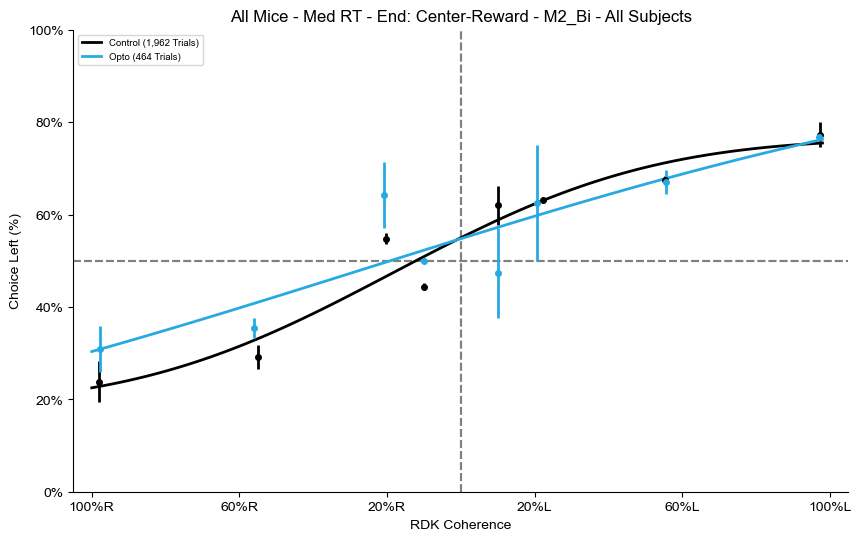

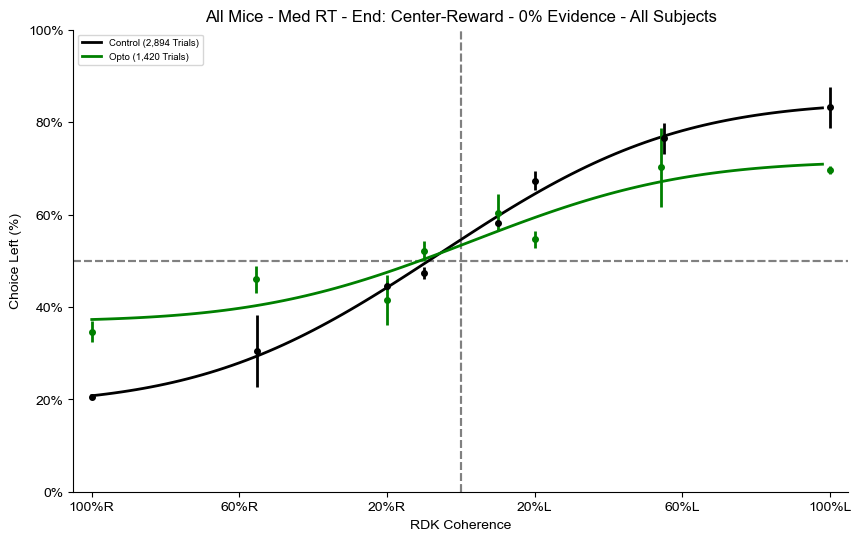

Max ST Values:


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,515.0,NaN,NaN,NaN,NaN
min,5.0,0.5,0.010100,0.501000,2023-07-05
max,5.0,0.5,24.799800,4.982500,2023-07-16
mean,5.0,0.5,1.581328,1.264187,NaN


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,134.0,NaN,NaN,NaN,NaN
min,5.0,0.5,0.049700,0.530900,2023-07-05
max,5.0,0.5,7.646100,4.982500,2023-07-05
mean,5.0,0.5,1.581743,1.261517,NaN


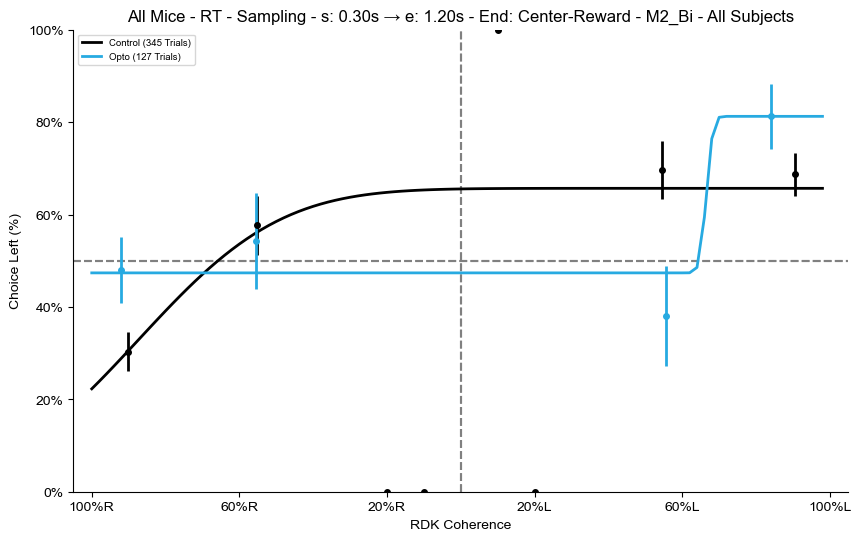

In [ ]:
control_common_kwargs = common_kwargs.copy()
control_common_kwargs.update(dict(only_control_animals=True,
                                   save_prefix=save_prefix + "Psychometric_Control/",
                                   save_figs=False,
                                  ))
loopPlotOptoEffect(df_opto,  stim_type="RT", which="all",
                   **control_common_kwargs,
                   )


df_full_sampling: 22955
End State: 11.0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.0                 1.0              11.0               1.0               14.0                 22955
dtype: int64

,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,22955.0,NaN,NaN,NaN,NaN
min,1.0,0.800000,0.000100,0.00010,2020-10-02
max,1.0,1.000000,1.035200,1.00020,2022-01-05
mean,1.0,0.995761,0.966667,0.96807,NaN


Start state: Sampling
Mean: 57.77777777777777 - SEM: nan - len(perf_col): 1
Mean: 53.333333333333336 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in s

Mean: 64.28571428571429 - SEM: nan - len(perf_col): 1
Mean: 73.33333333333333 - SEM: nan - len(perf_col): 1


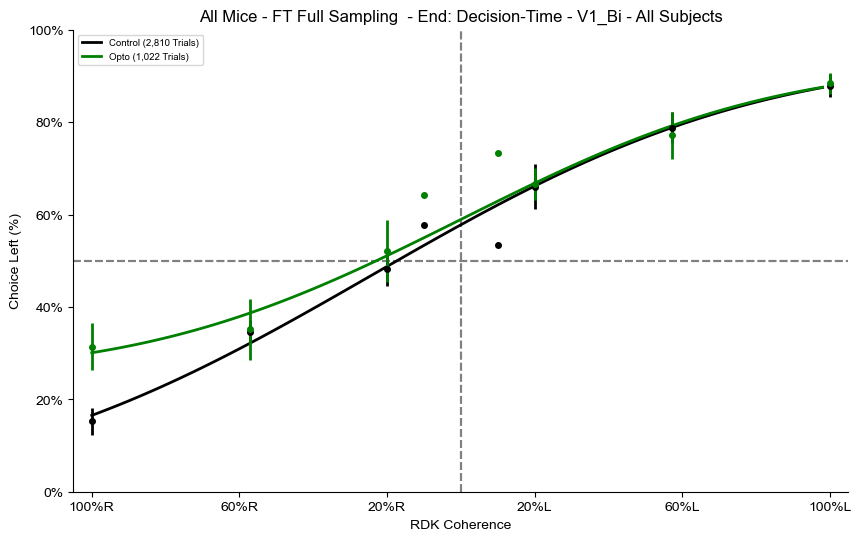

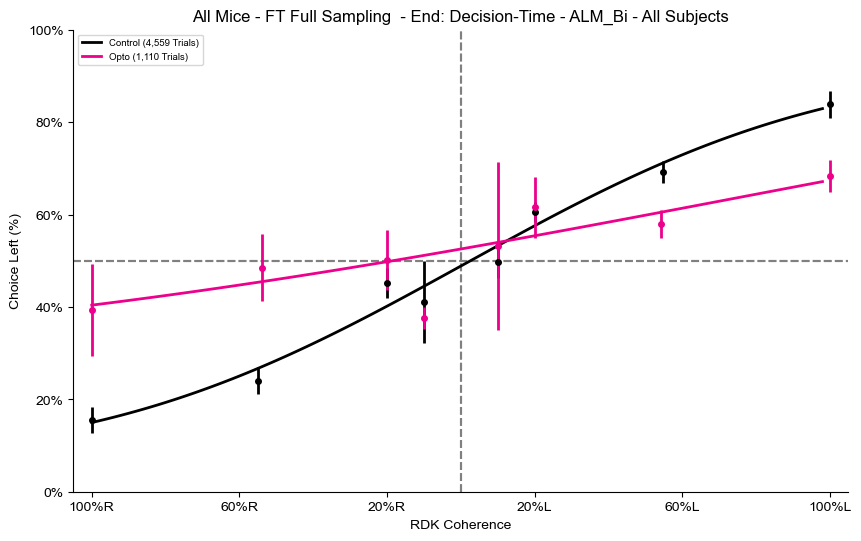

c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mean: 100.0 - SEM: nan - len(perf_col): 1


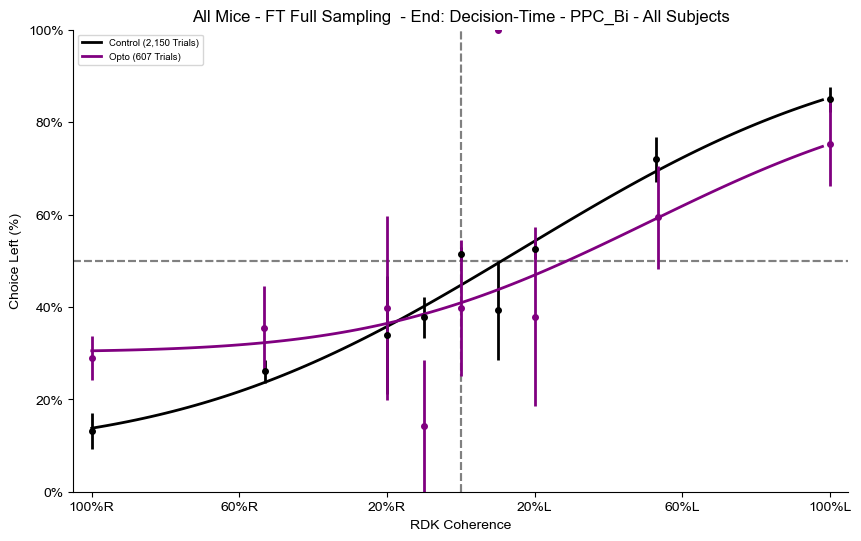

c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mean: 22.22222222222222 - SEM: nan - len(perf_col): 1
Mean: 34.78260869565217 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mean: 33.33333333333333 - SEM: nan - len(perf_col): 1
Mean: 70.0 - SEM: nan - len(perf_col): 1


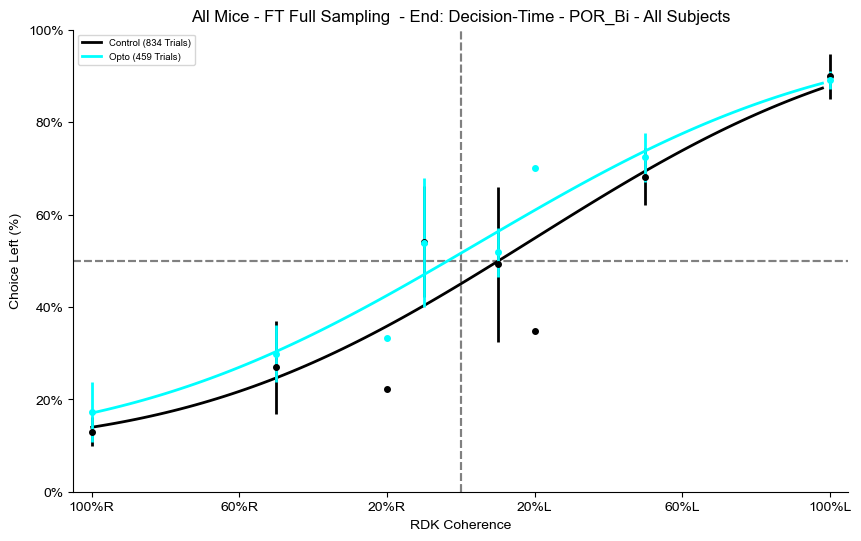

c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mean: 71.42857142857143 - SEM: nan - len(perf_col): 1


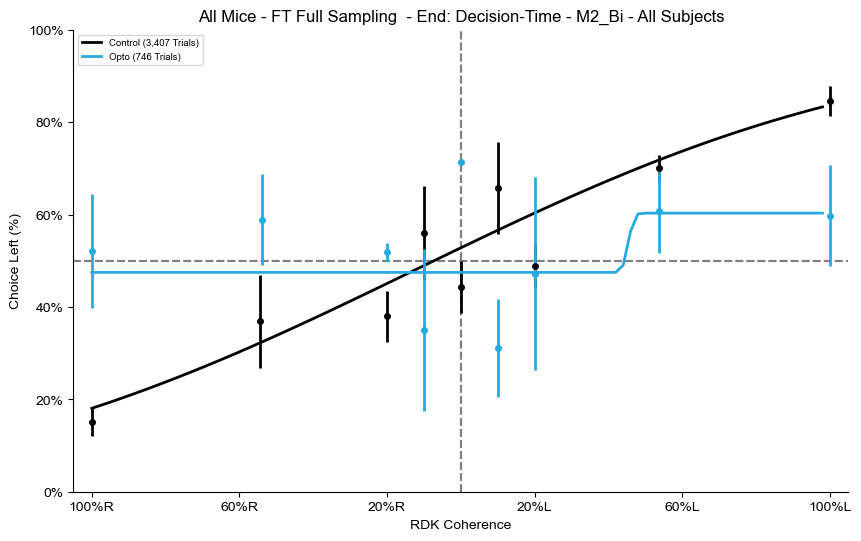

c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mean: 83.33333333333334 - SEM: nan - len(perf_col): 1
Mean: 72.72727272727273 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mean: 16.666666666666664 - SEM: nan - len(perf_col): 1
Mean: 50.0 - SEM: nan - len(perf_col): 1


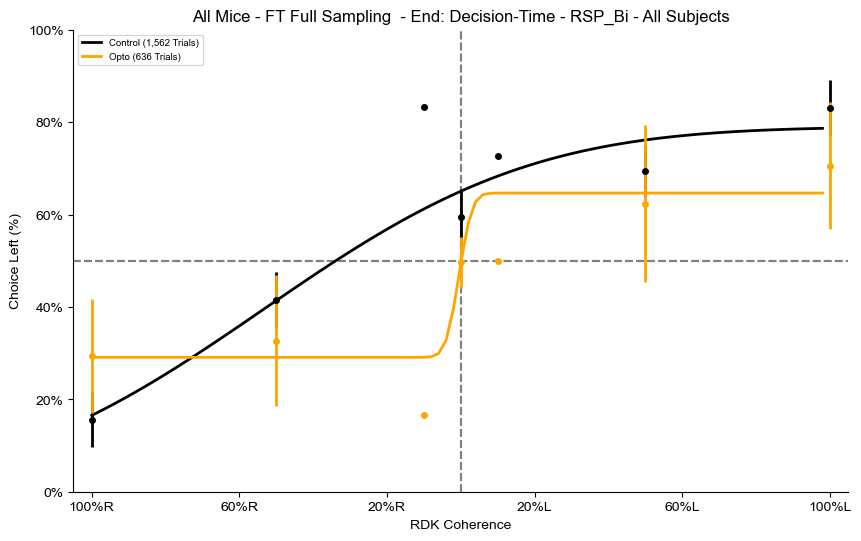

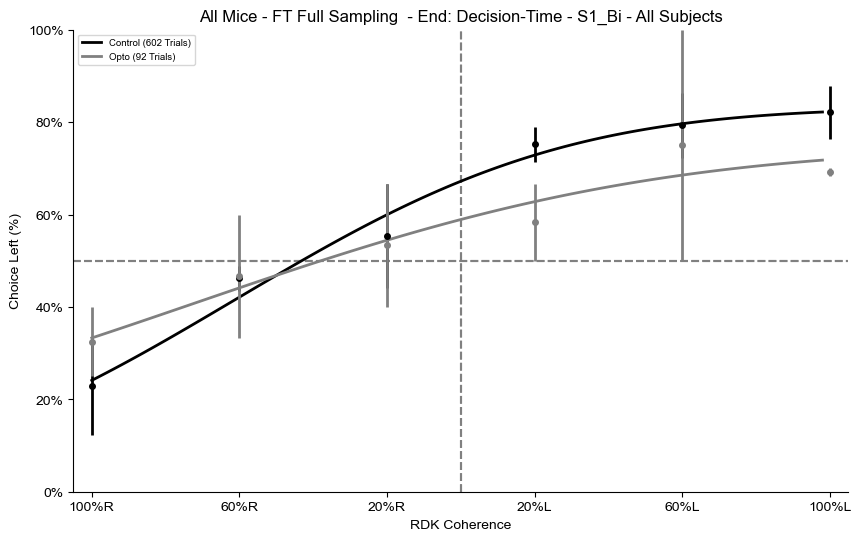

In [ ]:
loopPlotOptoEffect(df_opto, stim_type="FT", which="full",
                   **common_kwargs,
                   )

df_full_sampling: 22955


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.65                0.35             11.0               1.0               14.0                 16347
                     0.00                0.35             11.0               1.0               14.0                 15832
dtype: int64

Max ST Values:


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,15832.0,NaN,NaN,NaN,NaN
min,1.0,0.800000,0.000100,0.000100,2020-11-06
max,1.0,1.000000,1.035200,1.000200,2022-01-05
mean,1.0,0.996531,0.966488,0.964461,NaN


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,3493.0,NaN,NaN,NaN,NaN
min,1.0,0.810000,0.00010,0.002000,2020-11-06
max,1.0,1.000000,1.03520,1.000200,2022-01-05
mean,1.0,0.996565,0.93753,0.943584,NaN


Start state: Sampling


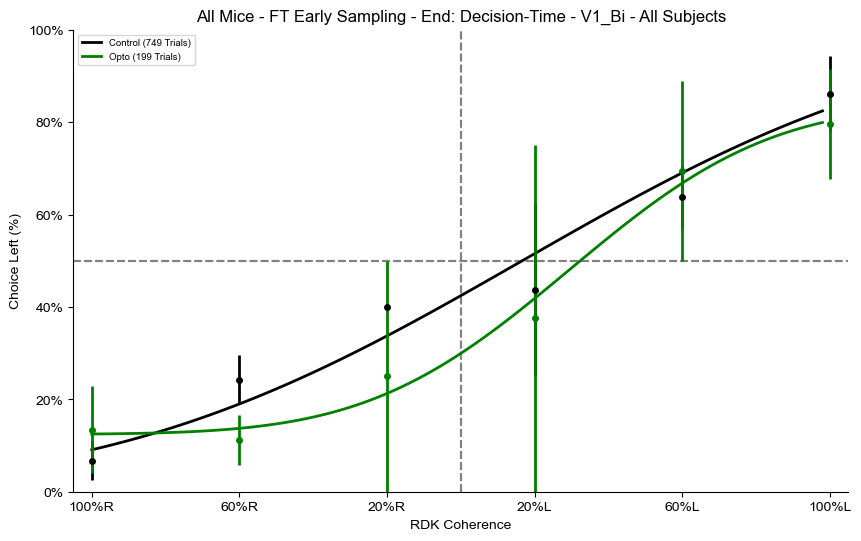

c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mean: 100.0 - SEM: nan - len(perf_col): 1
Mean: 66.66666666666666 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mean: 100.0 - SEM: nan - len(perf_col): 1
Mean: 33.33333333333333 - SEM: nan - len(perf_col): 1


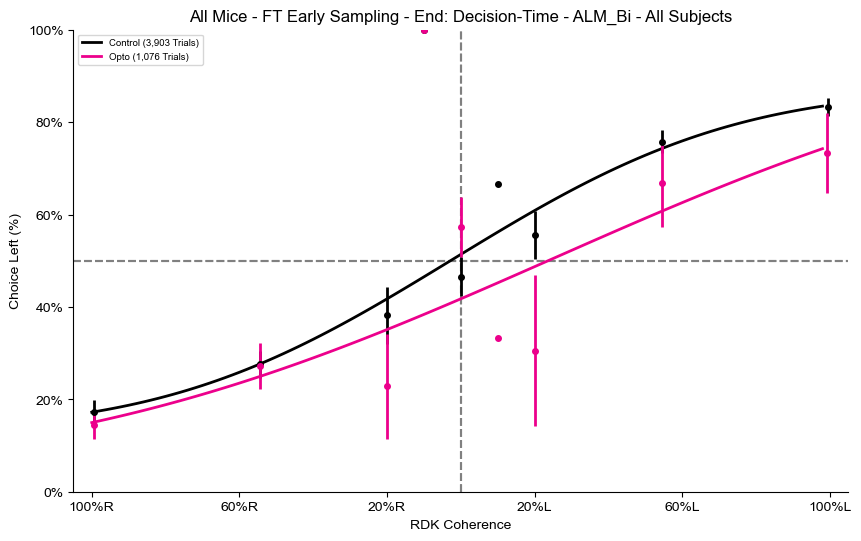

c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mean: 42.857142857142854 - SEM: nan - len(perf_col): 1
Mean: 66.66666666666666 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mean: 50.0 - SEM: nan - len(perf_col): 1
Mean: 50.0 - SEM: nan - len(perf_col): 1


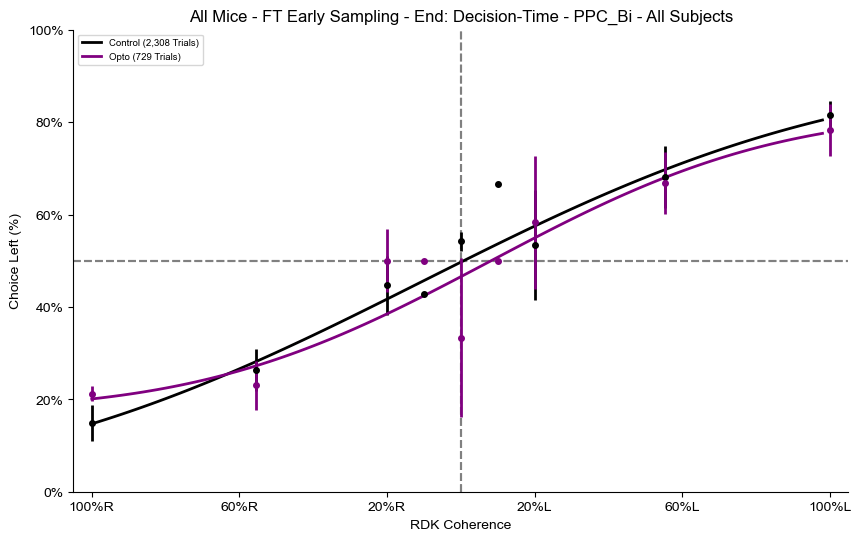

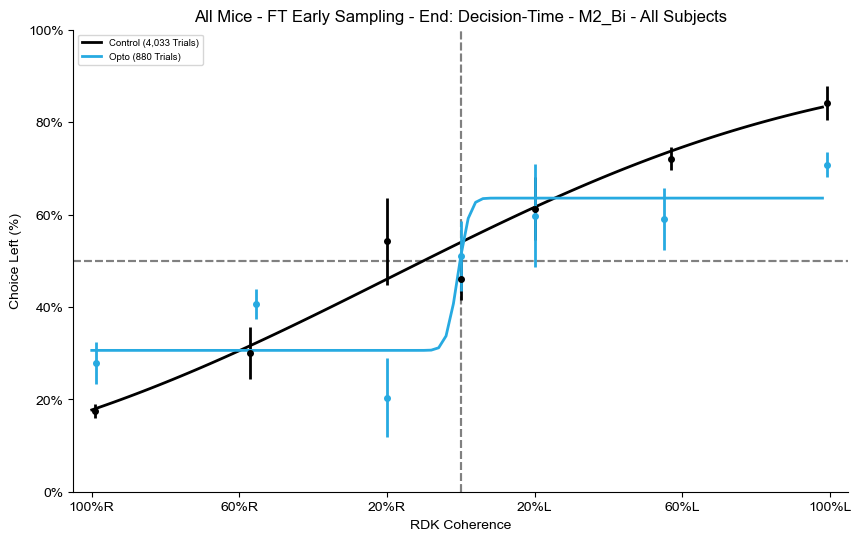

Max ST Values:


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,16347.0,NaN,NaN,NaN,NaN
min,1.0,0.82000,0.000400,0.000400,2020-11-06
max,1.0,1.00000,1.035200,1.000200,2022-01-05
mean,1.0,0.99778,0.989001,0.980025,NaN


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,3602.0,NaN,NaN,NaN,NaN
min,1.0,0.84000,0.00040,0.000400,2020-11-06
max,1.0,1.00000,1.03520,1.000200,2022-01-05
mean,1.0,0.99769,0.99238,0.979272,NaN


Start state: Sampling
Mean: 61.53846153846154 - SEM: nan - len(perf_col): 1
Mean: 62.5 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in s

Mean: 25.0 - SEM: nan - len(perf_col): 1
Mean: 75.0 - SEM: nan - len(perf_col): 1


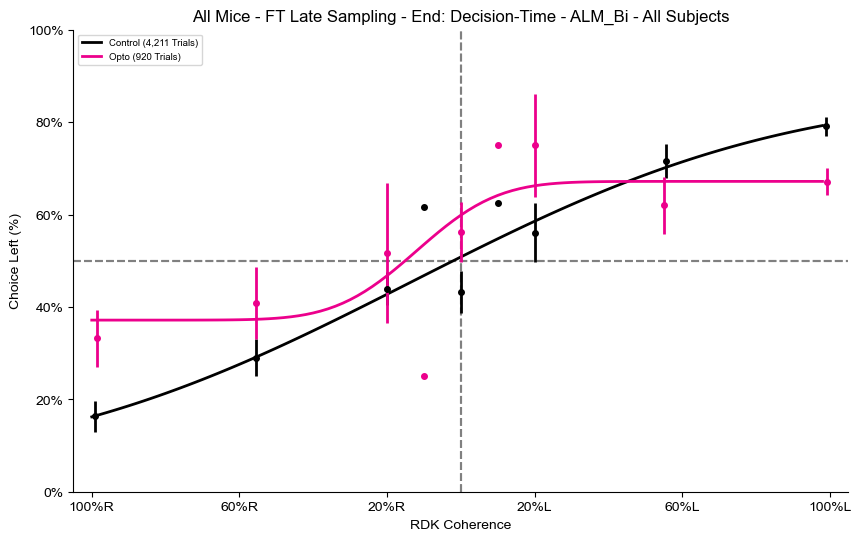

c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mean: 33.33333333333333 - SEM: nan - len(perf_col): 1
Mean: 43.333333333333336 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mean: 25.0 - SEM: nan - len(perf_col): 1
Mean: 53.333333333333336 - SEM: nan - len(perf_col): 1


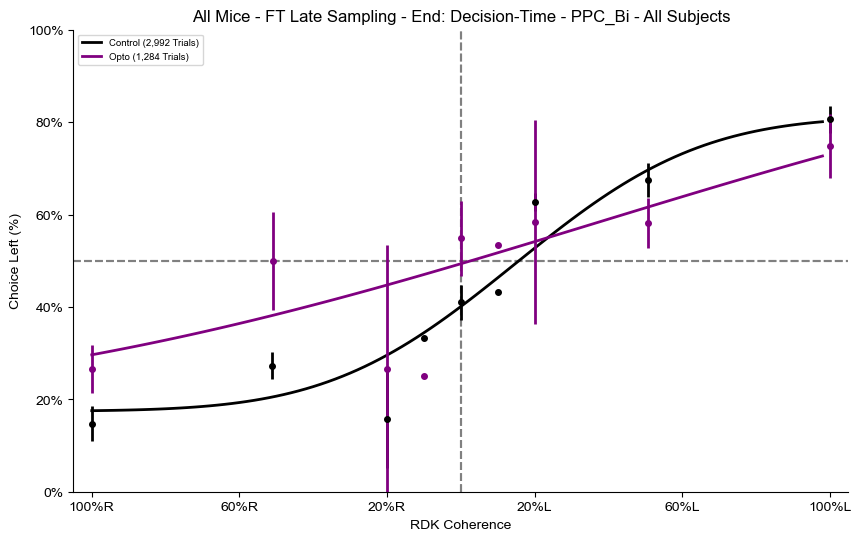

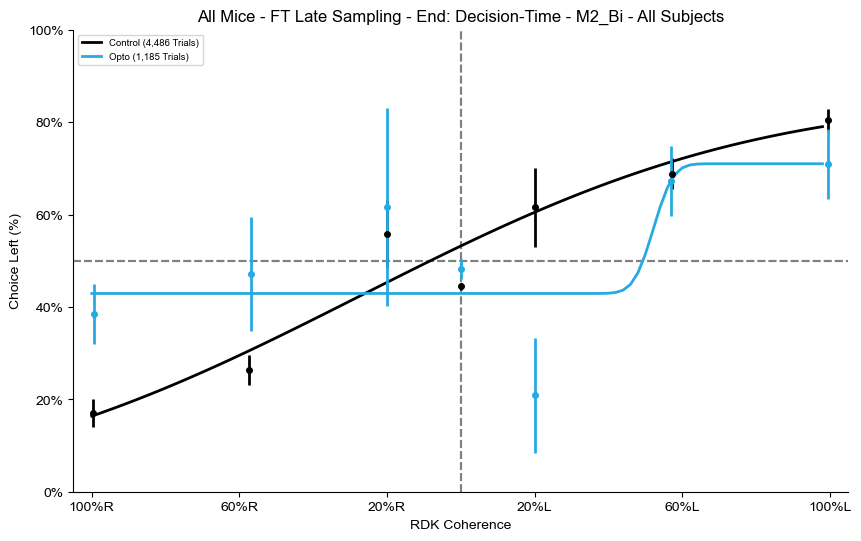

In [ ]:
loopPlotOptoEffect(df_opto,  stim_type="FT", which="partial",
                   **common_kwargs,
                   )